In [14]:
import os
import sys
print(sys.executable)
import numpy as np
import pandas as pd
import scipy
import torch
from sklearn import metrics

import pickle
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator

import warnings
import itertools
from tqdm import tqdm
import importlib
import utils


warnings.filterwarnings('ignore')

/admin/software/anaconda/1.11.1/envs/jupyter/bin/python


In [18]:
importlib.reload(utils)
from utils import *

In [19]:
%matplotlib inline

In [6]:
def load_gt(ct):
    """Load hicdc + pval for one ground truth sample."""
    with open(f"{HICHIP_BASE}/{ct}/zvalue/{ct}_hic_zscore_dict.p", "rb") as f:
        hicdc = pickle.load(f)
    with open(f"{HICHIP_BASE}/{ct}/qvalue/{ct}_hic_qvalue_dict.p", "rb") as f:
        pval = pickle.load(f)
    return hicdc, pval

In [7]:
# ── 1. Define subtype groupings ───────────────────────────────────────────────
# Ground truth ct samples per subtype (load hicdc/pval from these)
gt_subtypes = {
    "luminal": [
        "BRCA-5C54B79C-DA02-4B22-9FC2-3D61BFFC5559-X004-S02-B1-T1_H3K27ac",
        "BRCA-8D1E6006-85CB-484A-8B5C-30766D90137B-X005-S02-B1-T1_H3K27ac",
        "BRCA-14AD76EE-12F9-40B3-8DCD-4A256E02CF8D-X002-S03-B1-T1_H3K27ac",
        "BRCA-08499A64-3FD8-4E62-AF08-3C66AF93CAE7-X004-S03-B1-T1_H3K27ac",
        "BRCA-C9C8D426-A3FD-4455-89A9-768BC01D66A9-X003-S02-B1-T1_H3K27ac",    
    ],
    "basal": [
        "BRCA-7C6A3AE4-E2EA-42B3-B3F1-81C19E6F2170-X004-S01-B1-T1_H3K27ac",
        "BRCA-C147AAD5-A8F1-41D5-8709-21820BE50902-X005-S01-B1-T1_H3K27ac",
        "BRCA-CB96A542-7AC1-4FEC-A5D2-458D8EEDC6C4-X001-S01-B1-T1_H3K27ac",
        "BRCA-DD69EDE9-142D-46E2-AA06-58D07D3230FB-X002-S04-B1-T1_H3K27ac",
      
    ],
    "her2": [
        "BRCA-94AF19F0-1F2A-41EC-8CB6-96C76227811F-X003-S01-B1-T1_H3K27ac",
    ],
}

# Predicted ct2 samples per subtype (used for pred_base_path)
pred_subtypes = {
    "luminal": [
        "BRCA_Luminal",
    ],
    "basal": [
        "BRCA_Basal",
       
    ],
    "her2": [
       "BRCA_HER2",
    ],
}

In [ ]:
pred_subtypes = {
    "luminal": [
        "BRCA_5C54B79C_DA02_4B22_9FC2_3D61BFFC5559_X011_S02_B1_T1",
        "BRCA_8D1E6006_85CB_484A_8B5C_30766D90137B_X001_S01_B1_T1",
        "BRCA_14AD76EE_12F9_40B3_8DCD_4A256E02CF8D_X003_S02_B1_T1",
        "BRCA_08499A64_3FD8_4E62_AF08_3C66AF93CAE7_X009_S01_B1_T1",
        "BRCA_C9C8D426_A3FD_4455_89A9_768BC01D66A9_X009_S02_B1_T1",
    ],
    "basal": [
        "BRCA_7C6A3AE4_E2EA_42B3_B3F1_81C19E6F2170_X005_S02_B1_T1",
        "BRCA_C147AAD5_A8F1_41D5_8709_21820BE50902_X008_S02_B1_T1",
        "BRCA_CB96A542_7AC1_4FEC_A5D2_458D8EEDC6C4_X013_S06_B1_T1",
        "BRCA_DD69EDE9_142D_46E2_AA06_58D07D3230FB_X014_S08_B1_T1",
       
    ],
    "her2": [
       "BRCA_94AF19F0_1F2A_41EC_8CB6_96C76227811F_X013_S01_B1_T1",
    ],
}

In [10]:
# ── 2. Shared config ──────────────────────────────────────────────────────────
chrom_list = ["1", "14", "17", "20", "3", "6", "8"]
mod        = "chromafold_CTCFmotif"
metrics    = ["pearson", "spearman", "roc", "prc"]

HICHIP_BASE = "/data1/lesliec/carolw/projects/chromafold/preprocess/GBM-chan/hichip_GSC"
PRED_BASE   = "/data1/lesliec/carolw/projects/chromafold/predictions/GBM-chan"


In [6]:
# ── 3. Run all NxN comparisons ────────────────────────────────────────────────
all_results = {}   # label -> {metric -> {chrom -> mean_val}}
subtypes = list(gt_subtypes.keys())

for pred_sub in subtypes:
    for true_sub in subtypes:
        label = f"pred_{pred_sub}_vs_true_{true_sub}"
        print(f"Running: {label}")

        # Collect one result per (predicted sample, ground truth sample) pair
        sample_results = []
        for ct2 in pred_subtypes[pred_sub]:
            for ct in gt_subtypes[true_sub]:
                hicdc, pval = load_gt(ct)
                res = evaluate_predictions_by_chrom(
                    chrom_list,
                    hicdc=hicdc,
                    pval=pval,
                    ct2=ct2,
                    mod=mod,
                    pred_base_path=f"{PRED_BASE}/{ct2}",
                    plot=False,
                )
                sample_results.append(res)

        # Average all pairs per chrom → 7 values per metric
        averaged = {m: {} for m in metrics}
        for chrom in chrom_list:
            for m in metrics:
                vals = [np.nanmean(r[m][chrom]) for r in sample_results]
                averaged[m][chrom] = np.nanmean(vals)

        all_results[label] = averaged

Running: pred_MES/Proneural_vs_true_MES/Proneural


KeyError: 'MES/Proneural'

In [9]:
# ── 4. Save CSV ───────────────────────────────────────────────────────────────
rows = []
for label, avg in all_results.items():
    for chrom in chrom_list:
        rows.append({"comparison": label, "chrom": chrom,
                     **{m: avg[m][chrom] for m in metrics}})

df = pd.DataFrame(rows)
df.to_csv("/data1/lesliec/carolw/projects/chromafold/vis/brca_subtype_comparison_results.csv", index=False)

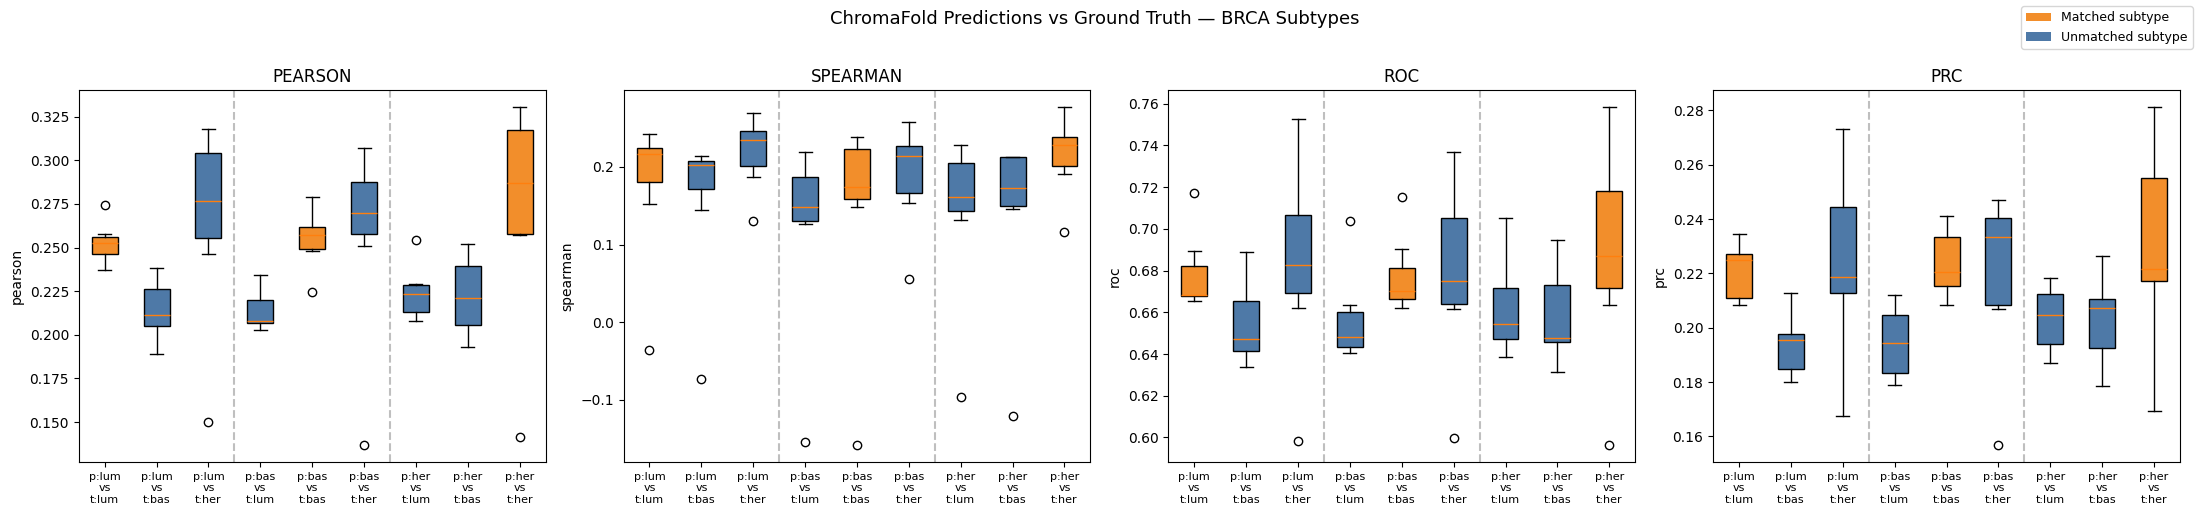

In [10]:
# ── 5. Boxplot ────────────────────────────────────────────────────────────────
labels_order = [f"pred_{p}_vs_true_{t}" for p in subtypes for t in subtypes]
short_labels  = [f"p:{p[:3]}\nvs\nt:{t[:3]}" for p in subtypes for t in subtypes]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, metric in zip(axes, metrics):
    data = [[all_results[l][metric][c] for c in chrom_list] for l in labels_order]
    bp = ax.boxplot(data, labels=short_labels, patch_artist=True)
    
    # Color matched (diagonal) boxes differently
    colors = ["#f28e2b" if p == t else "#4e79a7"
              for p in subtypes for t in subtypes]
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
    
    # Separator lines between pred-subtype groups
    for x in [3.5, 6.5]:
        ax.axvline(x=x, color="gray", linestyle="--", alpha=0.5)
    
    ax.set_title(metric.upper(), fontsize=12)
    ax.tick_params(axis="x", labelsize=8)
    ax.set_ylabel(metric)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#f28e2b", label="Matched subtype"),
                   Patch(facecolor="#4e79a7", label="Unmatched subtype")]
fig.legend(handles=legend_elements, loc="upper right", fontsize=9)

plt.suptitle("ChromaFold Predictions vs Ground Truth — BRCA Subtypes", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("brca_subtype_comparison_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
# GBM predicted subtype accuracy
t_subtypes = {
    "MES/Proneural": [
        "s320",   
    ],
    "CLS": [
        "s1206",
    ],
}

# Predicted ct2 samples per subtype (used for pred_base_path)
pred_subtypes = {
    "CLS": [
        "GBMx_NonImmune_Classical_2k",
       
    ],
    "Proneural": [
       "GBMx_NonImmune_Proneural_2k",
    ],
}

In [ ]:
# ── 2. Shared config ──────────────────────────────────────────────────────────
chrom_list = ["1", "19","4","7"]
mod        = "chromafold_CTCFmotif"
metrics    = ["pearson", "roc", "prc"]

HICHIP_BASE = "/data1/lesliec/carolw/projects/chromafold/preprocess/GBM-chan/hic_GSC"
PRED_BASE   = "/data1/lesliec/carolw/projects/chromafold/predictions/GBM-chan"


Running: pred_CLS_vs_true_MES/Proneural

===== Chromosome 1 =====


100%|█████████████████████████████| 24595/24595 [00:02<00:00, 10721.02it/s]



===== Chromosome 19 =====


100%|███████████████████████████████| 5561/5561 [00:00<00:00, 48417.65it/s]



===== Chromosome 4 =====


...

100%|███████████████████████████████| 5561/5561 [00:00<00:00, 47929.93it/s]



===== Chromosome 4 =====


100%|█████████████████████████████| 18721/18721 [00:01<00:00, 15096.93it/s]



===== Chromosome 7 =====


100%|█████████████████████████████| 15613/15613 [00:00<00:00, 17838.18it/s]


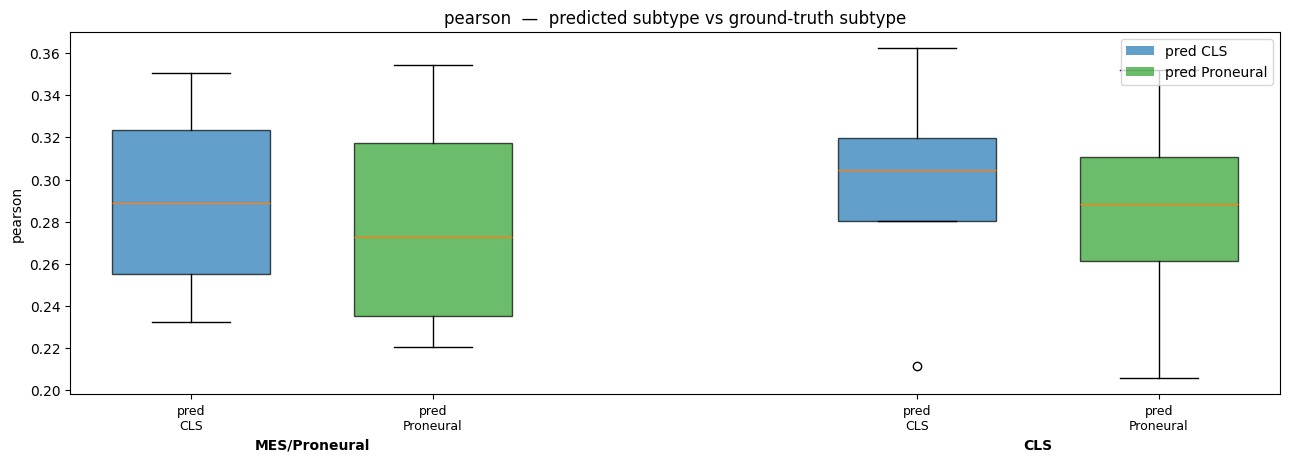

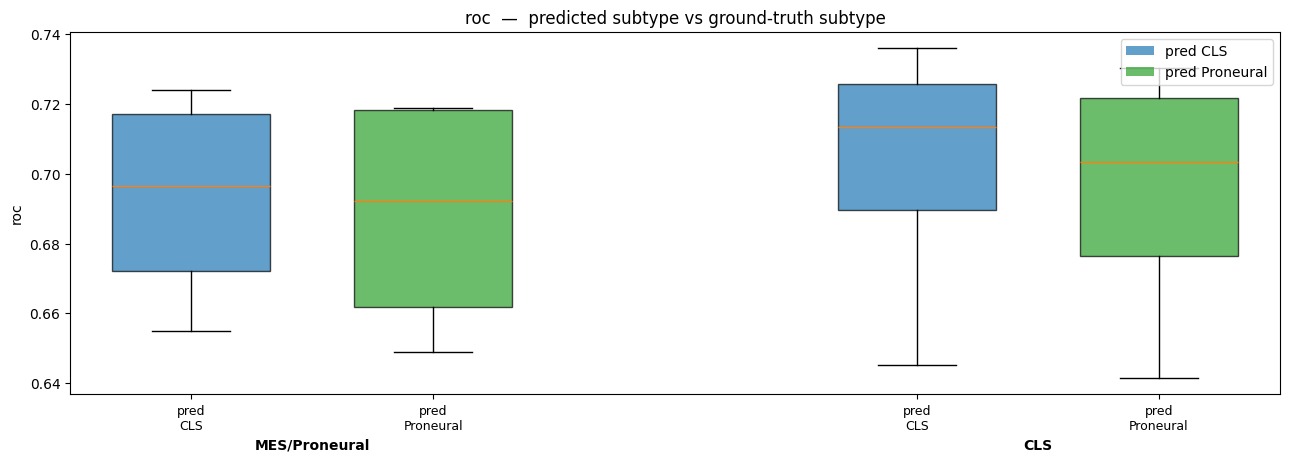

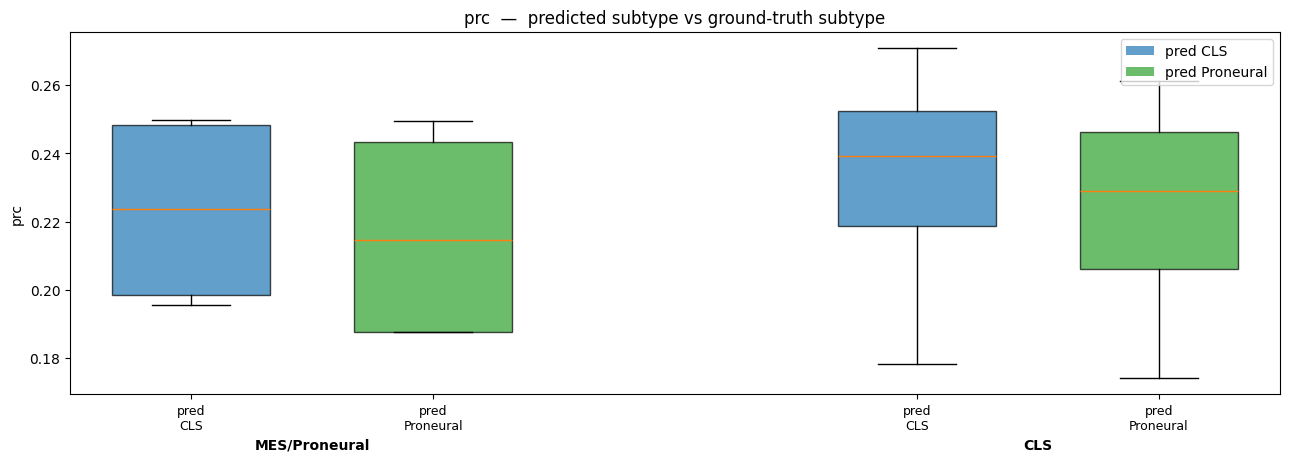

In [10]:
# ── 3. Run all 3x3 comparisons ────────────────────────────────────────────────
all_results = {}

pred_order = ["CLS", "Proneural"]
true_order = ["MES/Proneural", "CLS"]   # MES-like → CLS-like

for pred_sub in pred_order:
    for true_sub in true_order:
        label = f"pred_{pred_sub}_vs_true_{true_sub}"
        print(f"Running: {label}")

        sample_results = []
        for ct2 in pred_subtypes[pred_sub]:
            for ct in t_subtypes[true_sub]:
                hicdc, pval = load_gt(ct)
                res = evaluate_predictions_by_chrom(
                    chrom_list,
                    hicdc=hicdc,
                    pval=pval,
                    ct2=ct2,
                    mod=mod,
                    pred_base_path=f"{PRED_BASE}/{ct2}",
                    plot=False,
                )
                sample_results.append(res)

        averaged = {m: {} for m in metrics}
        for chrom in chrom_list:
            for m in metrics:
                vals = [np.nanmean(r[m][chrom]) for r in sample_results]
                averaged[m][chrom] = np.nanmean(vals)

        all_results[label] = averaged


# ── 4. Boxplots ───────────────────────────────────────────────────────────────
from matplotlib.patches import Patch

colors = {"CLS": "tab:blue", "Proneural": "tab:green"}

for metric in metrics:
    fig, ax = plt.subplots(figsize=(13, 5))

    data, positions, tick_labels, box_colors = [], [], [], []
    group_centers = []
    pos = 1

    for true_sub in true_order:
        group_start = pos
        for pred_sub in pred_order:
            label = f"pred_{pred_sub}_vs_true_{true_sub}"
            # One value per chrom → each box has len(chrom_list) points
            chrom_vals = [all_results[label][metric][chrom] for chrom in chrom_list]
            data.append(chrom_vals)
            positions.append(pos)
            tick_labels.append(f"pred\n{pred_sub}")
            box_colors.append(colors[pred_sub])
            pos += 1
        group_centers.append((group_start + pos - 1) / 2)
        pos += 1   # gap between true-subtype groups

    bp = ax.boxplot(data, positions=positions, patch_artist=True, widths=0.65)
    for patch, color in zip(bp["boxes"], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_xticks(positions)
    ax.set_xticklabels(tick_labels, fontsize=9)

    # Group labels below x-axis
    y_min = ax.get_ylim()[0]
    y_range = ax.get_ylim()[1] - y_min
    for center, true_sub in zip(group_centers, true_order):
        ax.text(center, y_min - 0.12 * y_range, true_sub,
                ha="center", va="top", fontsize=10, fontweight="bold")

    ax.set_title(f"{metric}  —  predicted subtype vs ground-truth subtype", fontsize=12)
    ax.set_ylabel(metric)

    legend_elements = [Patch(facecolor=colors[p], alpha=0.7, label=f"pred {p}") for p in pred_order]
    ax.legend(handles=legend_elements, loc="upper right")

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.2)   # room for group labels
    plt.show()

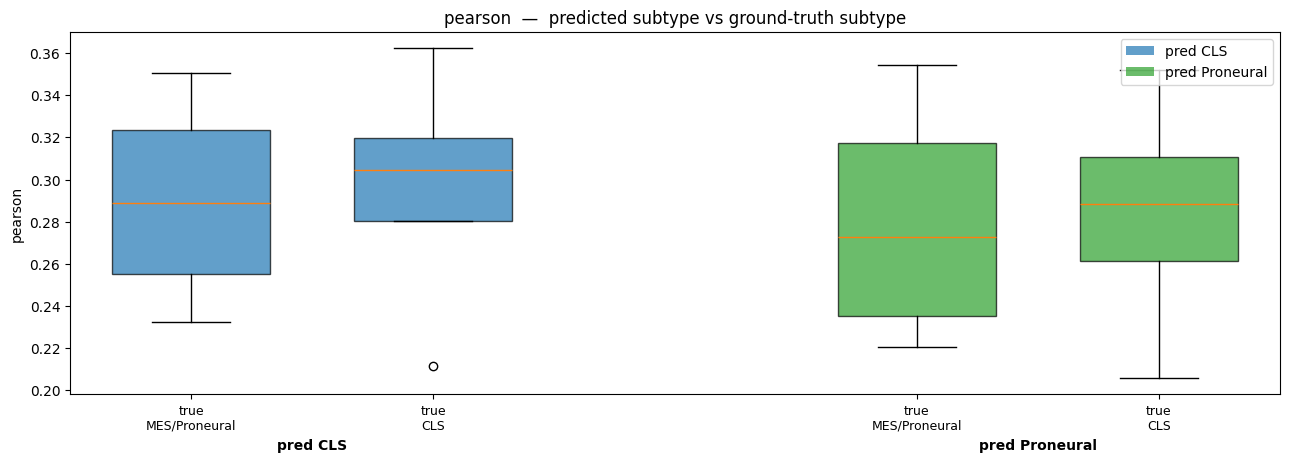

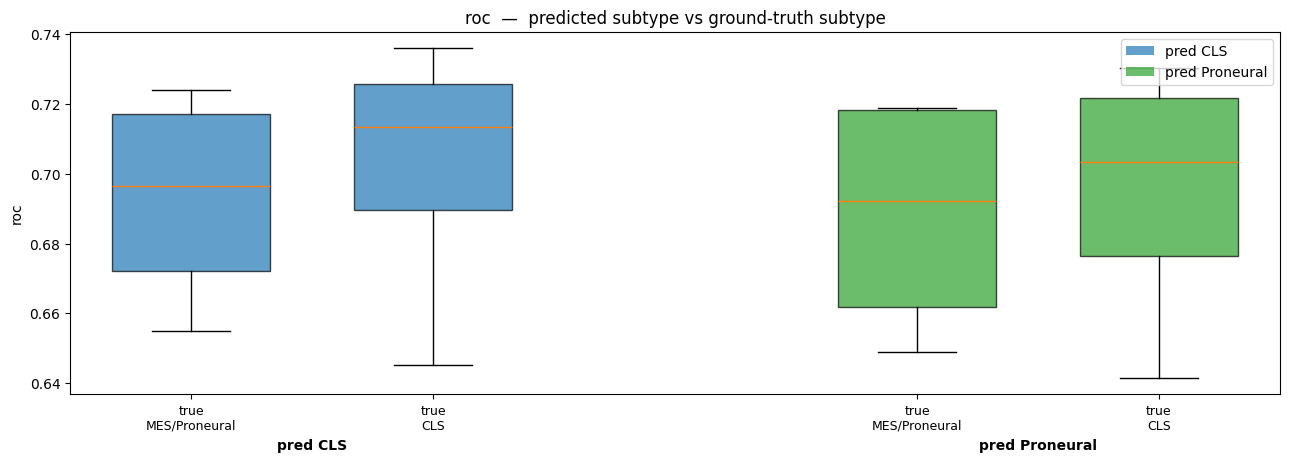

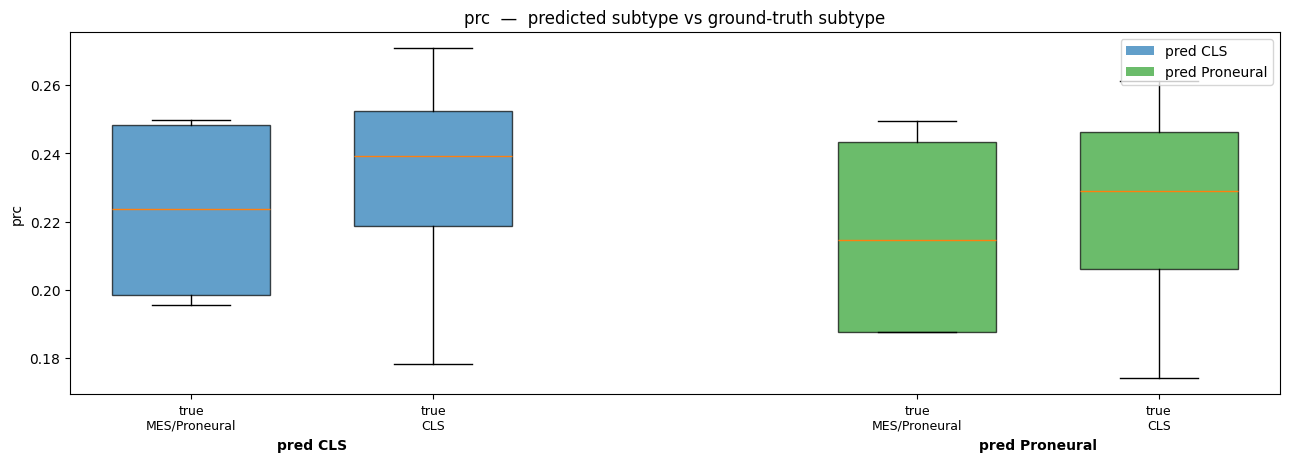

In [11]:

for metric in metrics:
    fig, ax = plt.subplots(figsize=(13, 5))

    data, positions, tick_labels, box_colors = [], [], [], []
    group_centers = []
    pos = 1

    for pred_sub in pred_order:
        group_start = pos
        for true_sub in true_order:
            label = f"pred_{pred_sub}_vs_true_{true_sub}"
            chrom_vals = [all_results[label][metric][chrom] for chrom in chrom_list]
            data.append(chrom_vals)
            positions.append(pos)
            tick_labels.append(f"true\n{true_sub}")
            box_colors.append(colors[pred_sub])
            pos += 1
        group_centers.append((group_start + pos - 1) / 2)
        pos += 1   # gap between predicted-subtype groups

    bp = ax.boxplot(data, positions=positions, patch_artist=True, widths=0.65)
    for patch, color in zip(bp["boxes"], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_xticks(positions)
    ax.set_xticklabels(tick_labels, fontsize=9)

    y_min = ax.get_ylim()[0]
    y_range = ax.get_ylim()[1] - y_min
    for center, pred_sub in zip(group_centers, pred_order):
        ax.text(center, y_min - 0.12 * y_range, f"pred {pred_sub}",
                ha="center", va="top", fontsize=10, fontweight="bold")

    ax.set_title(f"{metric}  —  predicted subtype vs ground-truth subtype", fontsize=12)
    ax.set_ylabel(metric)

    legend_elements = [Patch(facecolor=colors[p], alpha=0.7, label=f"pred {p}") for p in pred_order]
    ax.legend(handles=legend_elements, loc="upper right")

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.2)
    plt.show()

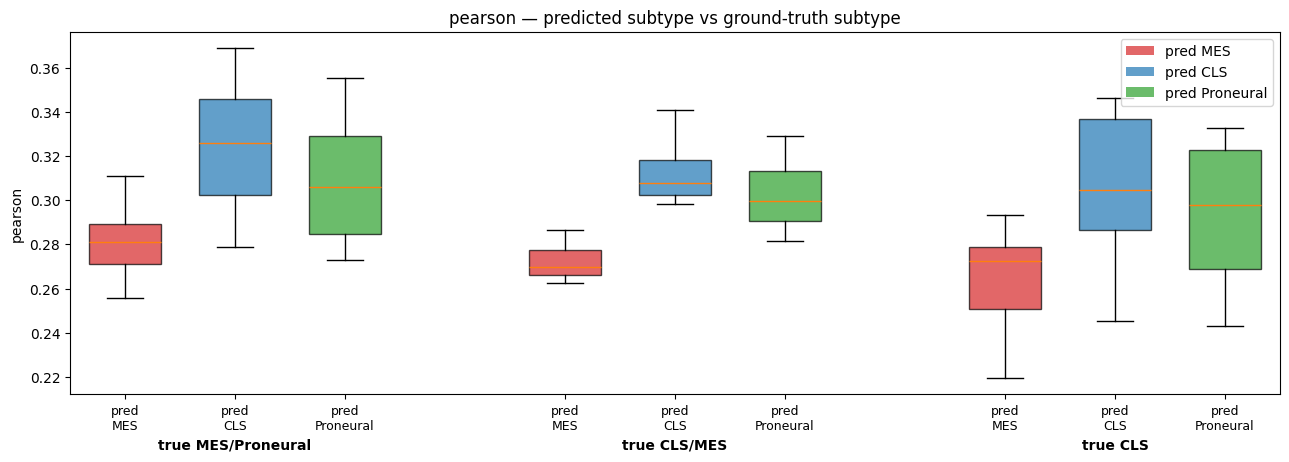

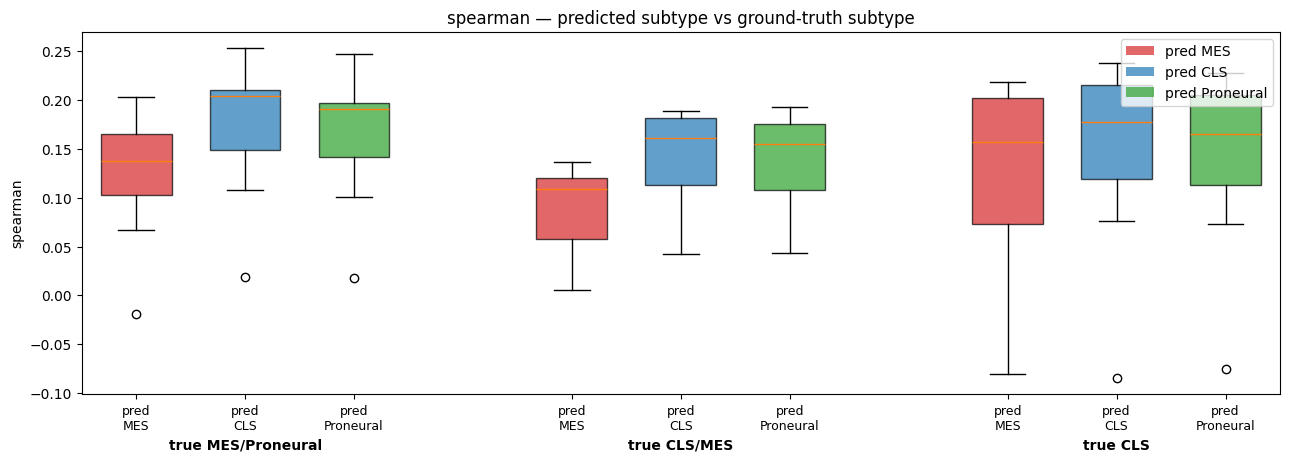

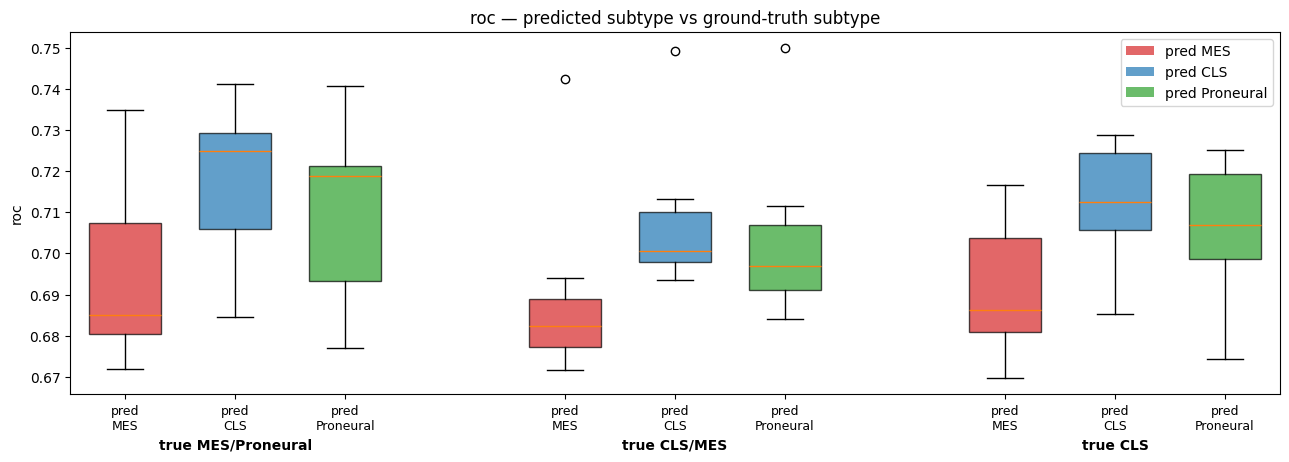

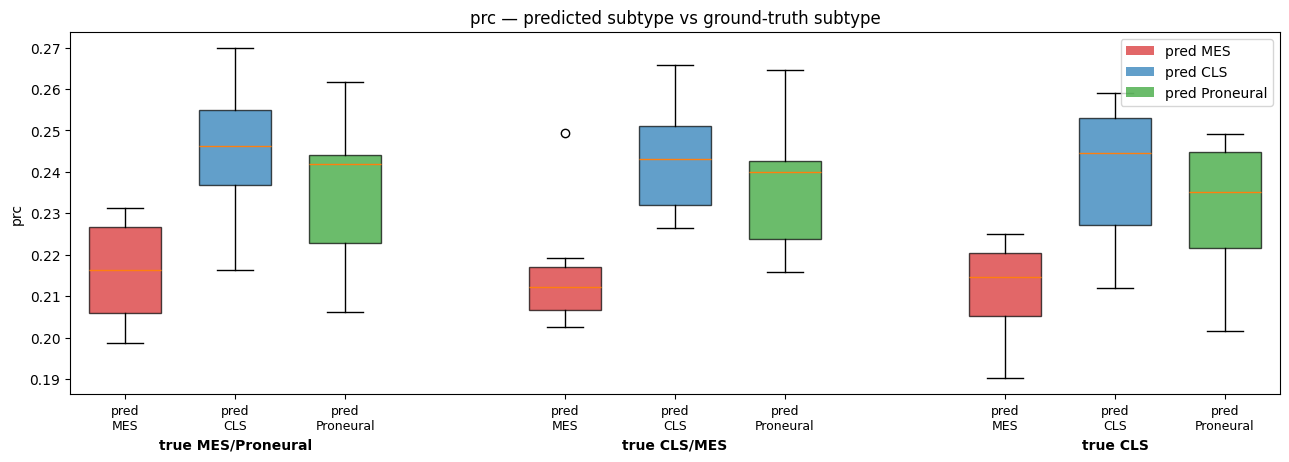

In [9]:
#group by ground truth
for metric in metrics:
    fig, ax = plt.subplots(figsize=(13, 5))

    data, positions, tick_labels, box_colors = [], [], [], []
    group_centers = []
    pos = 1

    for true_sub in true_order:   # group by ground truth
        group_start = pos
        for pred_sub in pred_order:
            label = f"pred_{pred_sub}_vs_true_{true_sub}"
            chrom_vals = [all_results[label][metric][chrom] for chrom in chrom_list]

            data.append(chrom_vals)
            positions.append(pos)
            tick_labels.append(f"pred\n{pred_sub}")
            box_colors.append(colors[pred_sub])
            pos += 1

        group_centers.append((group_start + pos - 1) / 2)
        pos += 1   # gap between ground-truth groups

    bp = ax.boxplot(data, positions=positions, patch_artist=True, widths=0.65)

    for patch, color in zip(bp["boxes"], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_xticks(positions)
    ax.set_xticklabels(tick_labels, fontsize=9)

    y_min = ax.get_ylim()[0]
    y_range = ax.get_ylim()[1] - y_min

    for center, true_sub in zip(group_centers, true_order):
        ax.text(center, y_min - 0.12 * y_range, f"true {true_sub}",
                ha="center", va="top", fontsize=10, fontweight="bold")

    ax.set_title(f"{metric} — predicted subtype vs ground-truth subtype", fontsize=12)
    ax.set_ylabel(metric)

    legend_elements = [Patch(facecolor=colors[p], alpha=0.7, label=f"pred {p}") for p in pred_order]
    ax.legend(handles=legend_elements, loc="upper right")

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.2)
    plt.show()

In [22]:
# predicted sample vs ground truth sample (distance stratified)
# Inputs
mod        = "chromafold_CTCFmotif"
chrom_list = ["1", "14", "17", "20", "3", "6", "8"]          
metrics    = ["roc", "prc", "pearson"]
distance_ranges = [(0, 17), (17, 45), (45, 98), (98, 200)]
dr_labels = {
    (0, 17):   "short",    # 0–170kb
    (17, 45):  "mid",      # 170–450kb
    (45, 98):  "long",     # 450–980kb
    (98, 200): "ultra",    # 980kb–2Mb
}

# Ground truth sample names (10 BRCA + 4 GBM = 14 total)
gt_samples = [
    "BRCA-5C54B79C-DA02-4B22-9FC2-3D61BFFC5559-X004-S02-B1-T1_H3K27ac",
    "BRCA-7C6A3AE4-E2EA-42B3-B3F1-81C19E6F2170-X004-S01-B1-T1_H3K27ac",
    "BRCA-8D1E6006-85CB-484A-8B5C-30766D90137B-X005-S02-B1-T1_H3K27ac",
    "BRCA-14AD76EE-12F9-40B3-8DCD-4A256E02CF8D-X002-S03-B1-T1_H3K27ac",
    "BRCA-94AF19F0-1F2A-41EC-8CB6-96C76227811F-X003-S01-B1-T1_H3K27ac",
    "BRCA-08499A64-3FD8-4E62-AF08-3C66AF93CAE7-X004-S03-B1-T1_H3K27ac",
    "BRCA-C9C8D426-A3FD-4455-89A9-768BC01D66A9-X003-S02-B1-T1_H3K27ac",
    "BRCA-C147AAD5-A8F1-41D5-8709-21820BE50902-X005-S01-B1-T1_H3K27ac",
    "BRCA-CB96A542-7AC1-4FEC-A5D2-458D8EEDC6C4-X001-S01-B1-T1_H3K27ac",
    "BRCA-DD69EDE9-142D-46E2-AA06-58D07D3230FB-X002-S04-B1-T1_H3K27ac",   # 10 BRCA
    "GBMx-09C0DCE7-D669-4D28-980D-BF71179116A4-X019-S06-B1-T1_H3K27ac",
    "GBMx-6BEE2CB6-9AFD-42A6-9C26-9C4428FBABFA-X009-S04-B1-T1_H3K27ac",
    "GBMx-9976F952-23A5-431A-A431-01E544324A26-X015-S02-B1-T1_H3K27ac",
    "GBMx-A90B18B6-6056-46D1-BF4E-70710236B8DD-X015-S07-B1-T1_H3K27ac",   # 4 GBM
]

# Corresponding predicted ct2 label for each sample (same order as gt_samples)
pred_samples = [
    "BRCA_5C54B79C_DA02_4B22_9FC2_3D61BFFC5559_X011_S02_B1_T1",
    "BRCA_7C6A3AE4_E2EA_42B3_B3F1_81C19E6F2170_X005_S02_B1_T1",
    "BRCA_8D1E6006_85CB_484A_8B5C_30766D90137B_X001_S01_B1_T1",
    "BRCA_14AD76EE_12F9_40B3_8DCD_4A256E02CF8D_X003_S02_B1_T1",
    "BRCA_94AF19F0_1F2A_41EC_8CB6_96C76227811F_X013_S01_B1_T1",
    "BRCA_08499A64_3FD8_4E62_AF08_3C66AF93CAE7_X009_S01_B1_T1",
    "BRCA_C9C8D426_A3FD_4455_89A9_768BC01D66A9_X009_S02_B1_T1",
    "BRCA_C147AAD5_A8F1_41D5_8709_21820BE50902_X008_S02_B1_T1",
    "BRCA_CB96A542_7AC1_4FEC_A5D2_458D8EEDC6C4_X013_S06_B1_T1",
    "BRCA_DD69EDE9_142D_46E2_AA06_58D07D3230FB_X014_S08_B1_T1", # 10 BRCA preds
    "GBMx_09C0DCE7_D669_4D28_980D_BF71179116A4_X005_S04_B1_T1",
    "GBMx_6BEE2CB6_9AFD_42A6_9C26_9C4428FBABFA_X004_S04_B1_T1",
    "GBMx_9976F952_23A5_431A_A431_01E544324A26_X010_S05_B1_T1",
    "GBMx_A90B18B6_6056_46D1_BF4E_70710236B8DD_X006_S04_B1_T1", # 4 GBM preds
]

# ── 0. Directory configs per cohort ───────────────────────────────────────────
BRCA_GT_BASE   = "/data1/lesliec/carolw/projects/chromafold/preprocess/BRCA-chan/hichip"
BRCA_PRED_BASE = "/data1/lesliec/carolw/projects/chromafold/predictions/BRCA-chan_1_3k"

GBM_GT_BASE    = "/data1/lesliec/carolw/projects/chromafold/preprocess/GBM-chan/hichip"
GBM_PRED_BASE  = "/data1/lesliec/carolw/projects/chromafold/predictions/GBM-chan_1_3k"

# ── 0b. Name mappings (translated from R) ─────────────────────────────────────
brca_map = {
    "BRCA_08499A64_3FD8_4E62_AF08_3C66AF93CAE7_X009_S01_B1_T1": "LumA2",
    "BRCA_14AD76EE_12F9_40B3_8DCD_4A256E02CF8D_X003_S02_B1_T1": "LumB2",
    "BRCA_5C54B79C_DA02_4B22_9FC2_3D61BFFC5559_X011_S02_B1_T1": "LumA1",
    "BRCA_7C6A3AE4_E2EA_42B3_B3F1_81C19E6F2170_X005_S02_B1_T1": "Basal1",
    "BRCA_8D1E6006_85CB_484A_8B5C_30766D90137B_X001_S01_B1_T1":  "LumB1",
    "BRCA_94AF19F0_1F2A_41EC_8CB6_96C76227811F_X013_S01_B1_T1":  "Her2",
    "BRCA_C147AAD5_A8F1_41D5_8709_21820BE50902_X008_S02_B1_T1":  "Basal2",
    "BRCA_C9C8D426_A3FD_4455_89A9_768BC01D66A9_X009_S02_B1_T1":  "LumB3",
    "BRCA_CB96A542_7AC1_4FEC_A5D2_458D8EEDC6C4_X013_S06_B1_T1":  "Basal3",
    "BRCA_DD69EDE9_142D_46E2_AA06_58D07D3230FB_X014_S08_B1_T1":  "Basal4",
}

gbm_map = {
    "GBMx_09C0DCE7_D669_4D28_980D_BF71179116A4_X005_S04_B1_T1": 5,
    "GBMx_6BEE2CB6_9AFD_42A6_9C26_9C4428FBABFA_X004_S04_B1_T1": 4,
    "GBMx_9976F952_23A5_431A_A431_01E544324A26_X010_S05_B1_T1":  6,
    "GBMx_A90B18B6_6056_46D1_BF4E_70710236B8DD_X006_S04_B1_T1":  7,
}


In [21]:
def get_short_label(pred_name):
    if pred_name in brca_map:
        return f"BRCA_{brca_map[pred_name]}"
    elif pred_name in gbm_map:
        return f"GBM_{gbm_map[pred_name]}"
    return pred_name   # fallback

def get_cohort(pred_name):
    return "BRCA" if pred_name.startswith("BRCA") else "GBM"

def get_pred_base(pred_name):
    return BRCA_PRED_BASE if pred_name.startswith("BRCA") else GBM_PRED_BASE

def get_gt_base(gt_name):
    return BRCA_GT_BASE if gt_name.startswith("BRCA") else GBM_GT_BASE
    
def load_gt(gt_name):
    base = get_gt_base(gt_name)
    with open(f"{base}/{gt_name}/zvalue/{gt_name}_hic_zscore_dict.p", "rb") as f:
        hicdc = pickle.load(f)
    with open(f"{base}/{gt_name}/qvalue/{gt_name}_hic_qvalue_dict.p", "rb") as f:
        pval = pickle.load(f)
    return hicdc, pval

In [8]:
# ── 1. Evaluate all 14 paired comparisons ─────────────────────────────────────
all_results  = {}
short_labels = []
sample_types = []

for gt_name, pred_ct2 in zip(gt_samples, pred_samples):
    short  = get_short_label(pred_ct2)
    cohort = get_cohort(pred_ct2)
    short_labels.append(short)
    sample_types.append(cohort)
    print(f"Evaluating: {short}  ({gt_name})")

    hicdc, pval = load_gt(gt_name)

    eval_result = evaluate_predictions_by_chrom(
        chrom_list, hicdc=hicdc, pval=pval,
        ct2=pred_ct2, mod=mod,
        pred_base_path=f"{get_pred_base(pred_ct2)}/{pred_ct2}",
        plot=False,
    )

    all_results[short] = aggregate_by_distance_range(
        eval_result, distance_ranges, chrom_list
    )



Evaluating: BRCA_LumA1  (BRCA-5C54B79C-DA02-4B22-9FC2-3D61BFFC5559-X004-S02-B1-T1_H3K27ac)

===== Chromosome 1 =====


100%|██████████████████████████████████| 24595/24595 [00:02<00:00, 10545.10it/s]



===== Chromosome 14 =====


100%|██████████████████████████████████| 10404/10404 [00:00<00:00, 27361.02it/s]



===== Chromosome 17 =====


...

100%|██████████████████████████████████| 19502/19502 [00:01<00:00, 14782.42it/s]



===== Chromosome 6 =====


100%|██████████████████████████████████| 16780/16780 [00:01<00:00, 16673.94it/s]



===== Chromosome 8 =====


100%|██████████████████████████████████| 14213/14213 [00:00<00:00, 19551.30it/s]


In [11]:
with open("/data1/lesliec/carolw/projects/chromafold/vis/all_results.pkl", "wb") as f:
    pickle.dump({
        "short_labels": short_labels,
        "sample_types": sample_types
    }, f)

In [17]:
all_results

{'BRCA_LumA1': {'pearson': {(0, 17): {'1': np.float64(0.5545035801016851),
    '14': np.float64(0.551812682335913),
    '17': np.float64(0.5751360145932753),
    '20': np.float64(0.5876478833086957),
    '3': np.float64(0.5251214048549873),
    '6': np.float64(0.5438741319200024),
    '8': np.float64(0.6089457837064691)},
   (17, 45): {'1': np.float64(0.40110889154315565),
    '14': np.float64(0.3966213299781978),
    '17': np.float64(0.40681928501883435),
    '20': np.float64(0.4133266060135909),
    '3': np.float64(0.37714620105333646),
    '6': np.float64(0.3866853976120579),
    '8': np.float64(0.47211582850031925)},
   (45, 98): {'1': np.float64(0.250079072157756),
    '14': np.float64(0.26092489598066376),
    '17': np.float64(0.25721854232585634),
    '20': np.float64(0.2371406909534911),
    '3': np.float64(0.23318119848833593),
    '6': np.float64(0.23221944984411974),
    '8': np.float64(0.26873946384117725)},
   (98, 200): {'1': np.float64(0.1513997438757848),
    '14': np.f

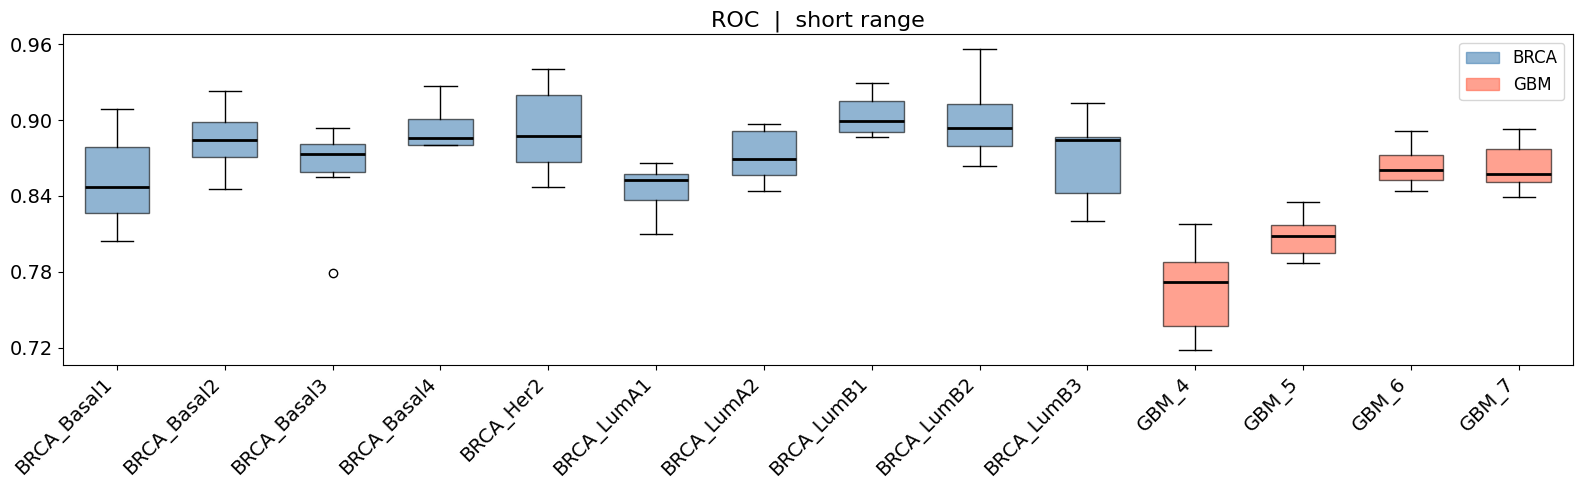

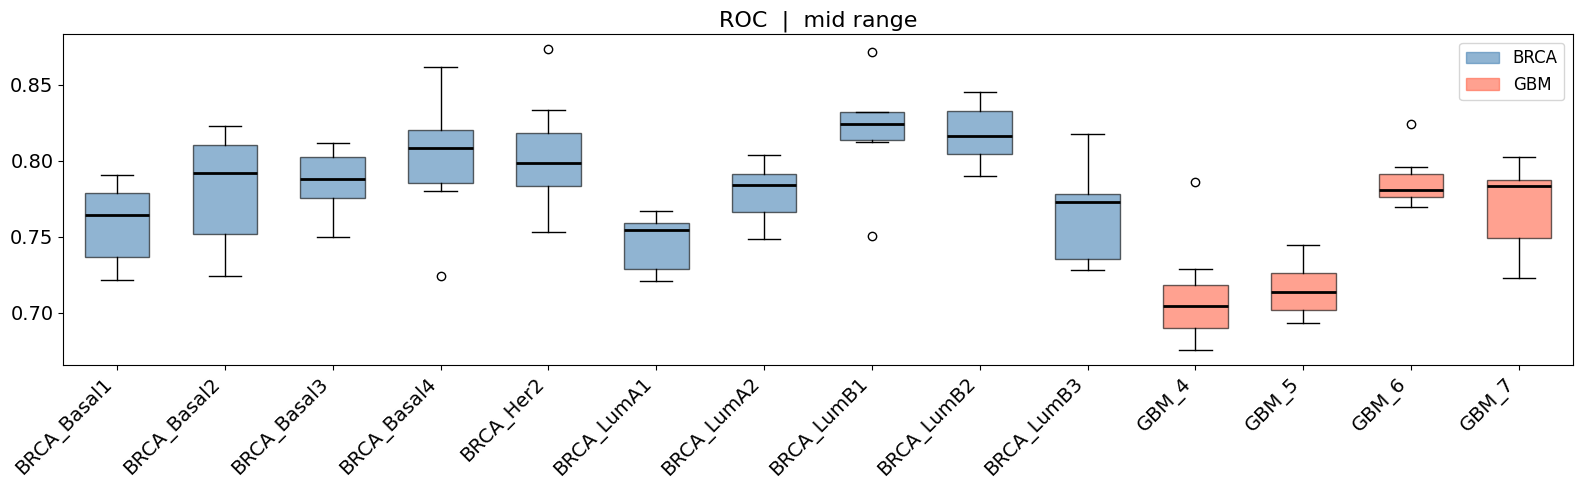

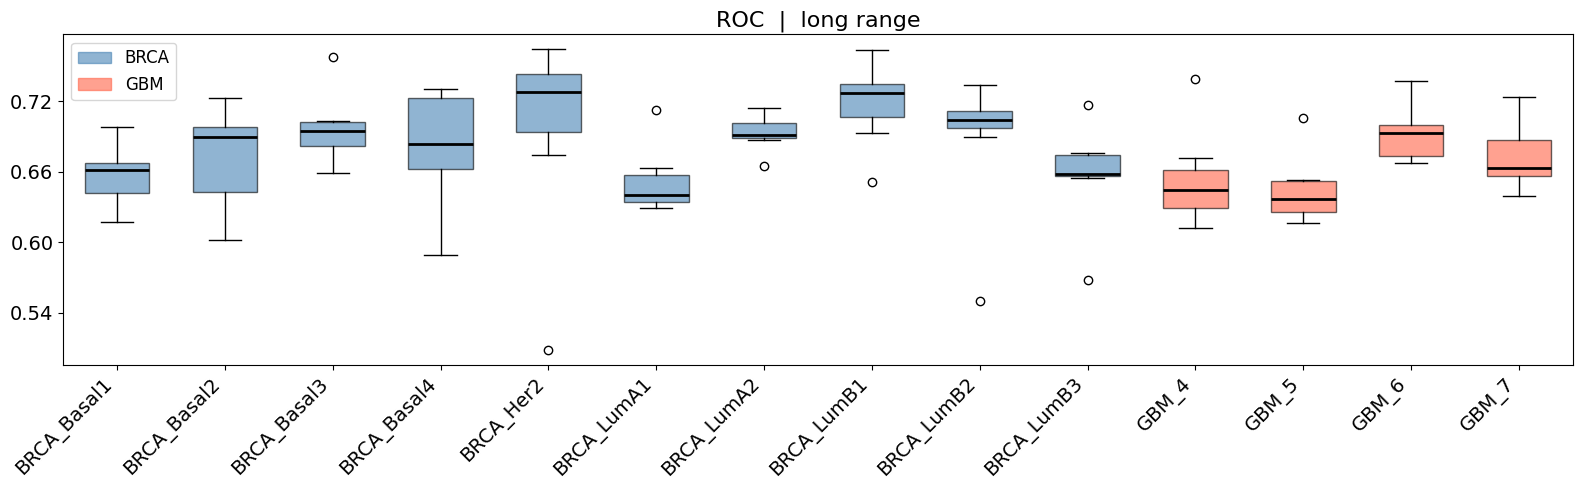

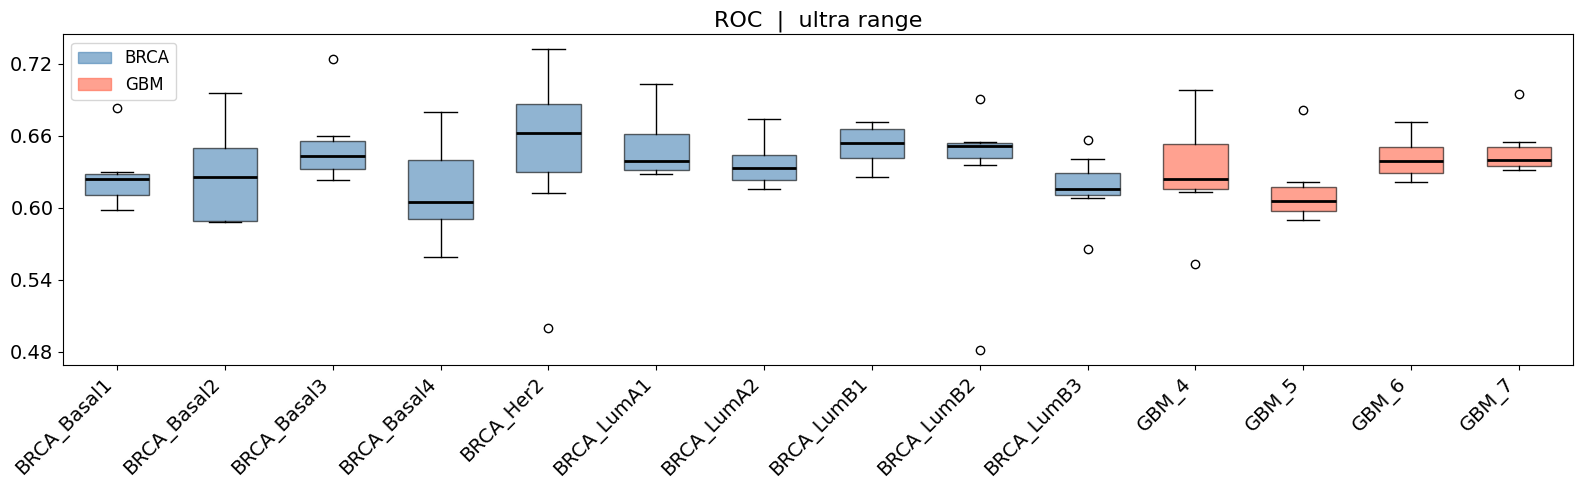

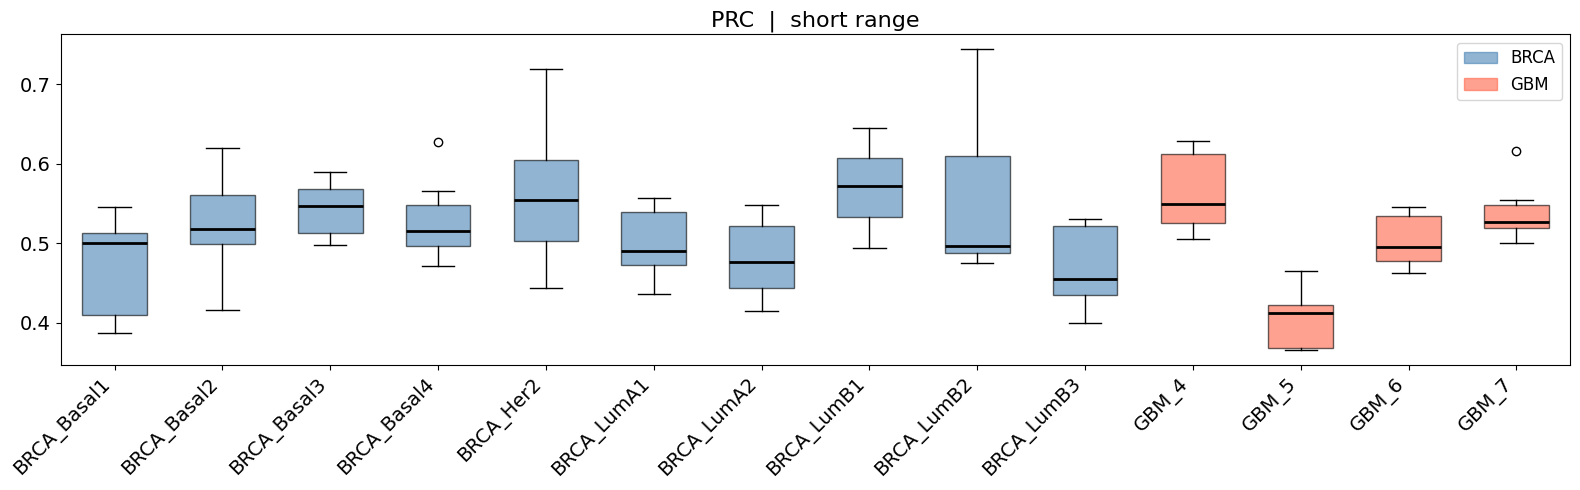

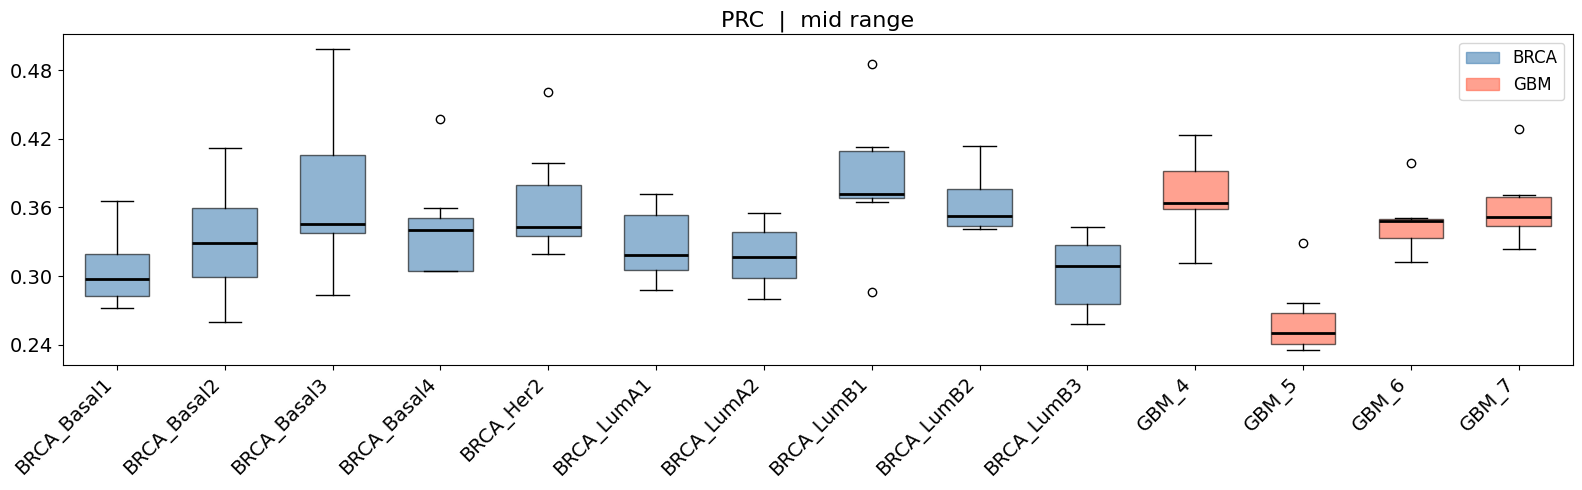

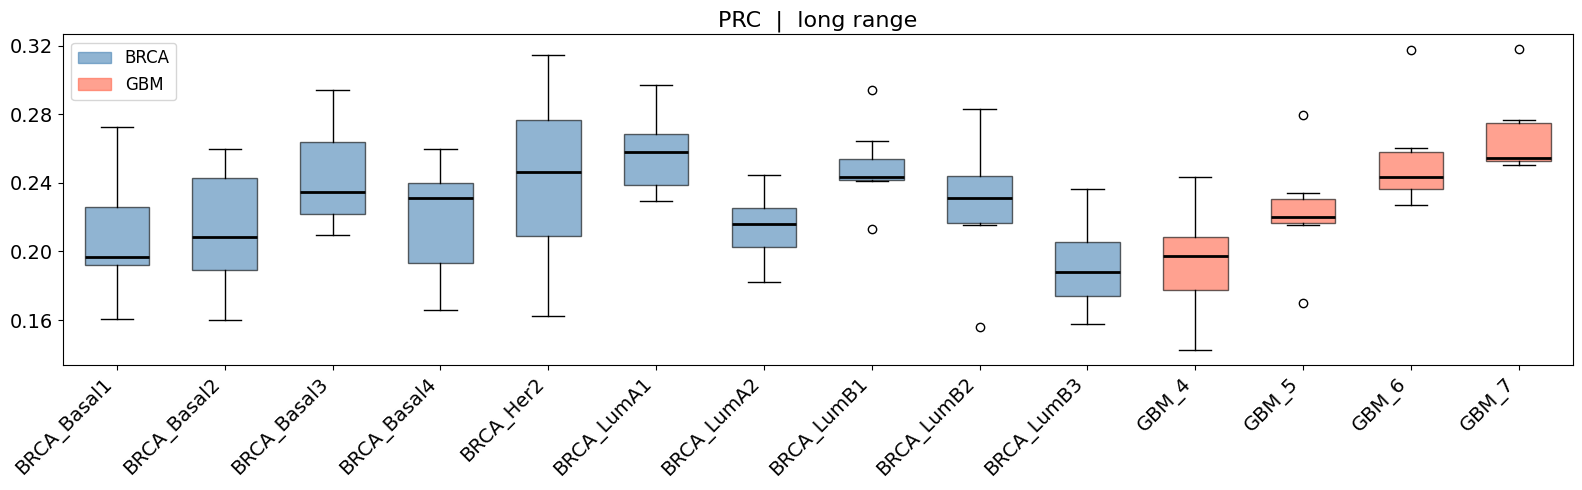

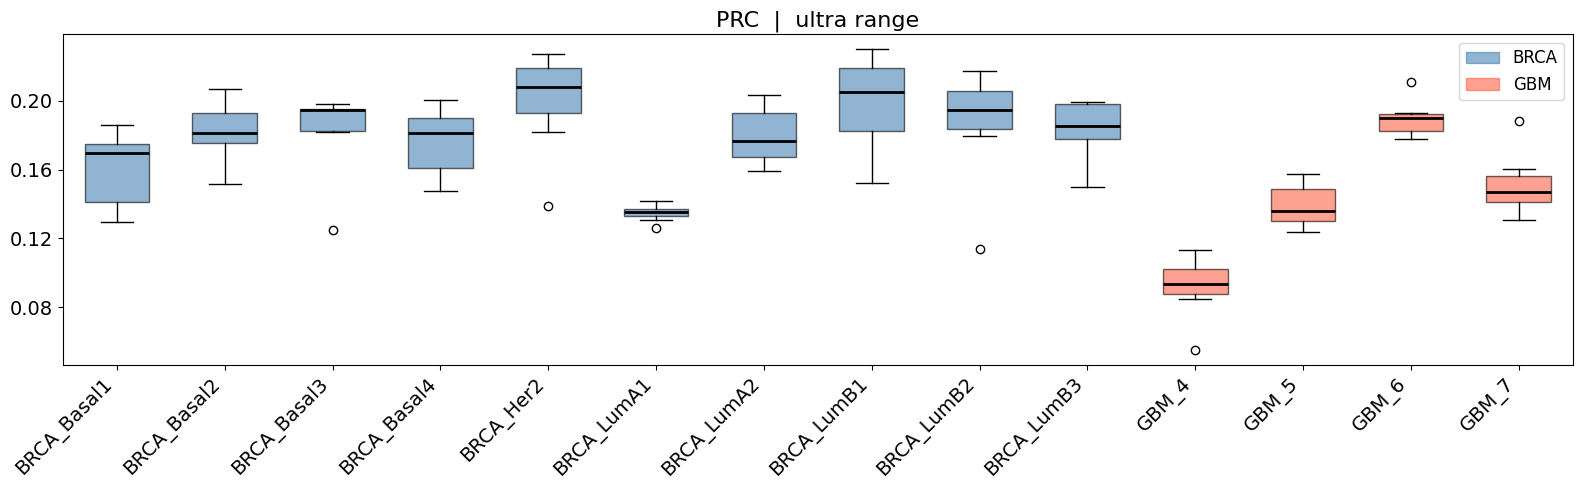

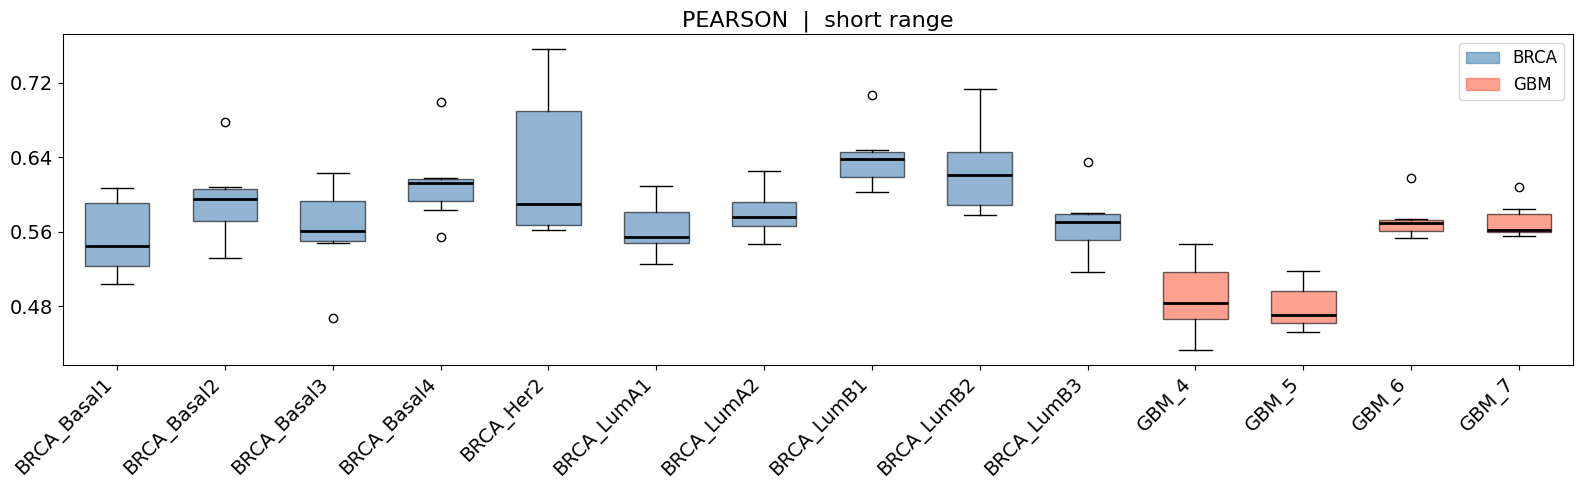

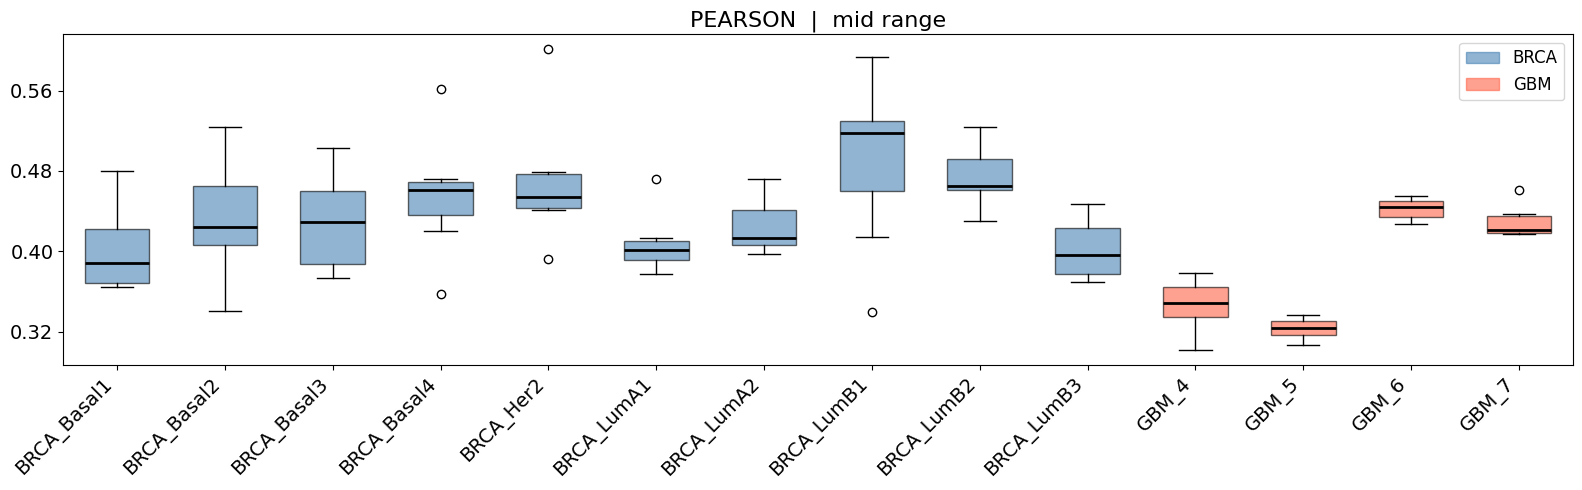

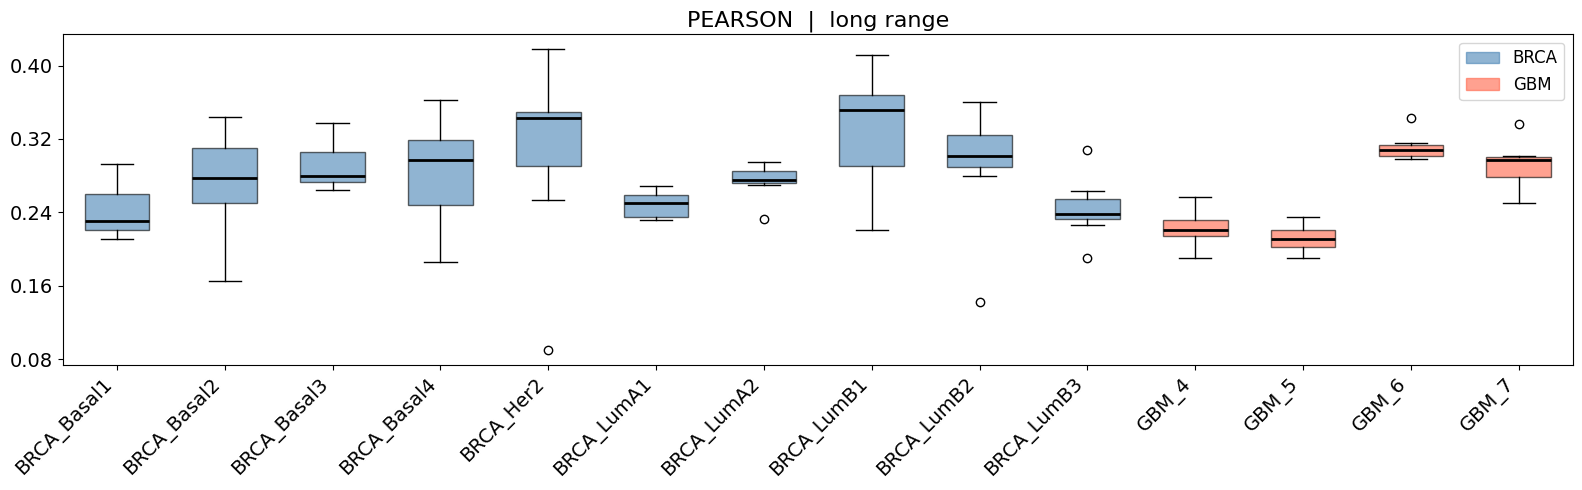

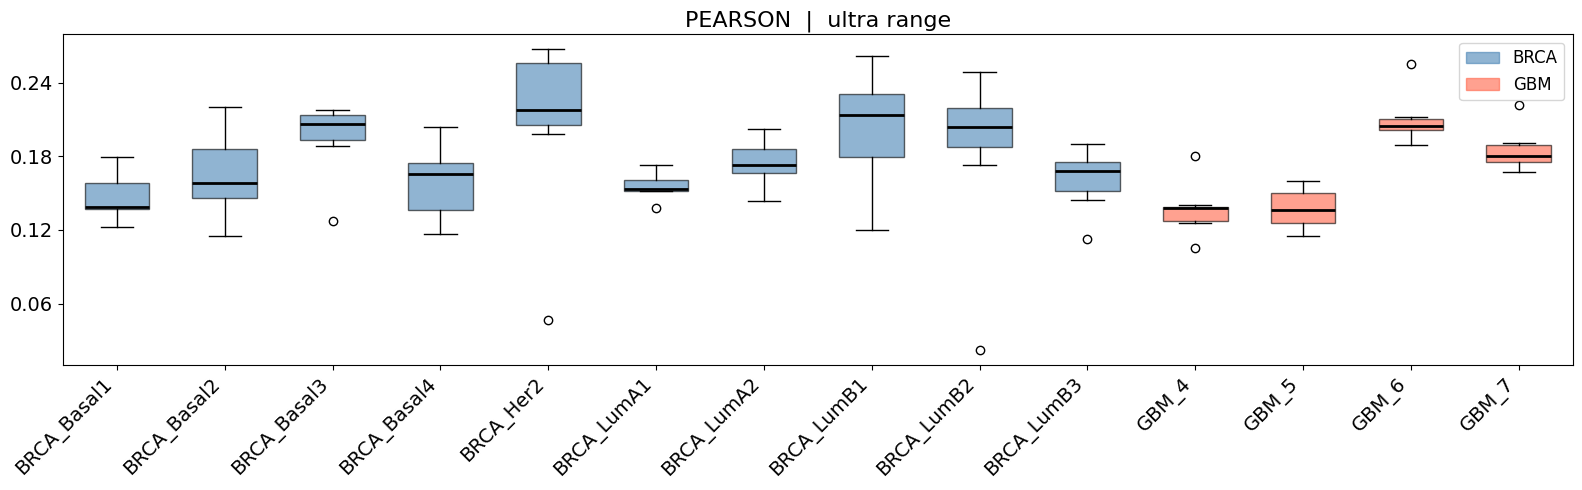

In [24]:
type_colors = {"BRCA": "steelblue", "GBM": "tomato"}

# --- sort labels alphabetically and reorder sample_types accordingly ---
sorted_pairs = sorted(zip(short_labels, sample_types), key=lambda x: x[0])
short_labels, sample_types = zip(*sorted_pairs)

for metric in metrics:
    for dr in distance_ranges:
        fig, ax = plt.subplots(figsize=(16, 5))

        box_data  = []
        positions = list(range(1, len(short_labels) + 1))

        for short in short_labels:
            chrom_vals = [
                all_results[short][metric][dr][str(c).replace("chr", "")]
                for c in chrom_list
            ]
            box_data.append(chrom_vals)

        bp = ax.boxplot(
            box_data, positions=positions,
            patch_artist=True, widths=0.6,
            medianprops=dict(color="black", linewidth=2)
        )

        # Color boxes by cohort
        for patch, s_type in zip(bp["boxes"], sample_types):
            patch.set_facecolor(type_colors[s_type])
            patch.set_alpha(0.6)

        ax.set_xticks(positions)
        ax.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=14)  # bigger labels
        #ax.set_ylabel(metric.upper(), fontsize=14)
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))   # fewer ticks
        ax.tick_params(axis='y', labelsize=14)             # larger tick labels
        ax.set_title(f"{metric.upper()}  |  {dr_labels[dr]} range", fontsize=16)

        legend_handles = [
            mpatches.Patch(color=type_colors[t], alpha=0.6, label=t)
            for t in ["BRCA", "GBM"]
        ]
        ax.legend(handles=legend_handles, loc="best", fontsize=12)

        plt.tight_layout()
        plt.show()

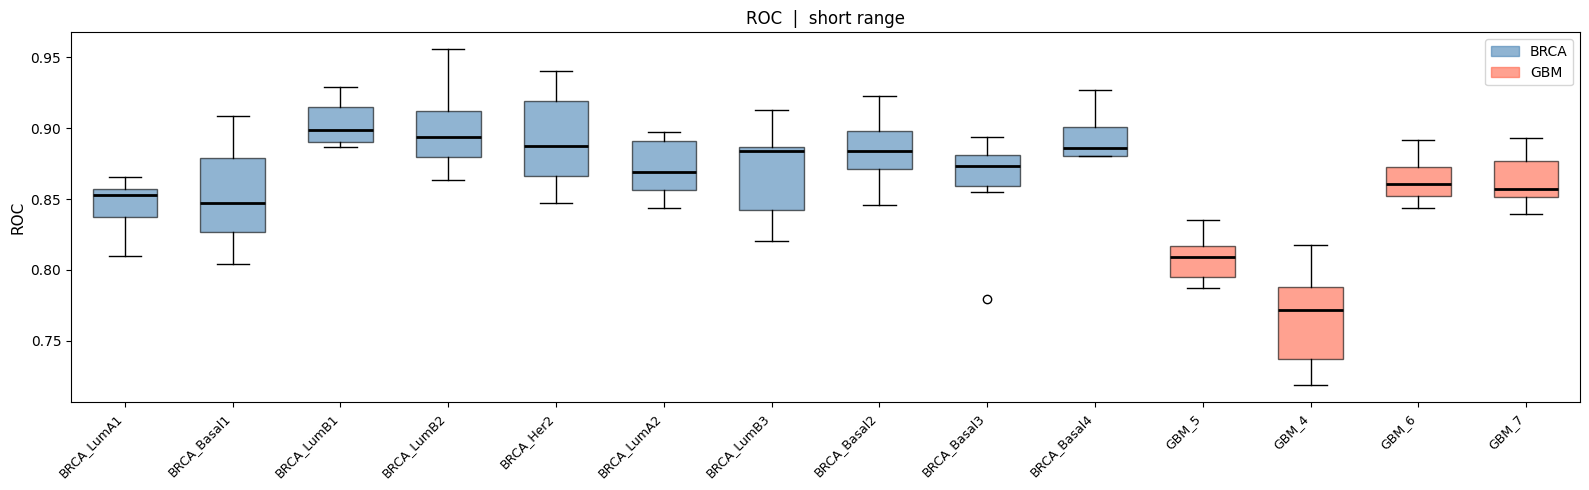

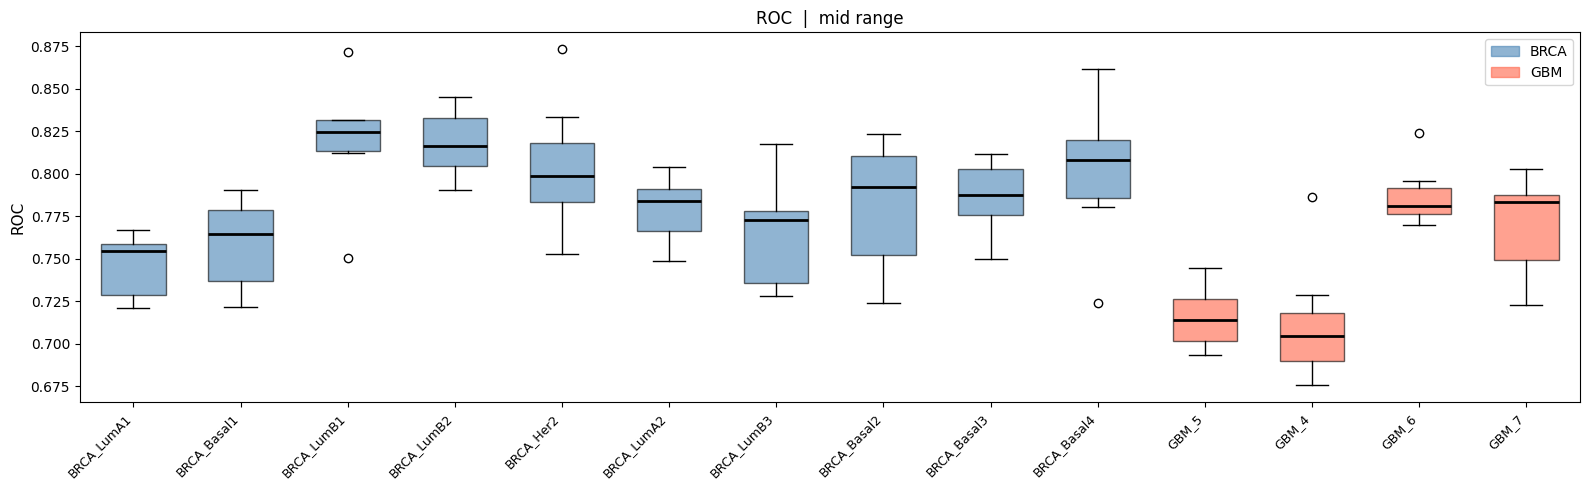

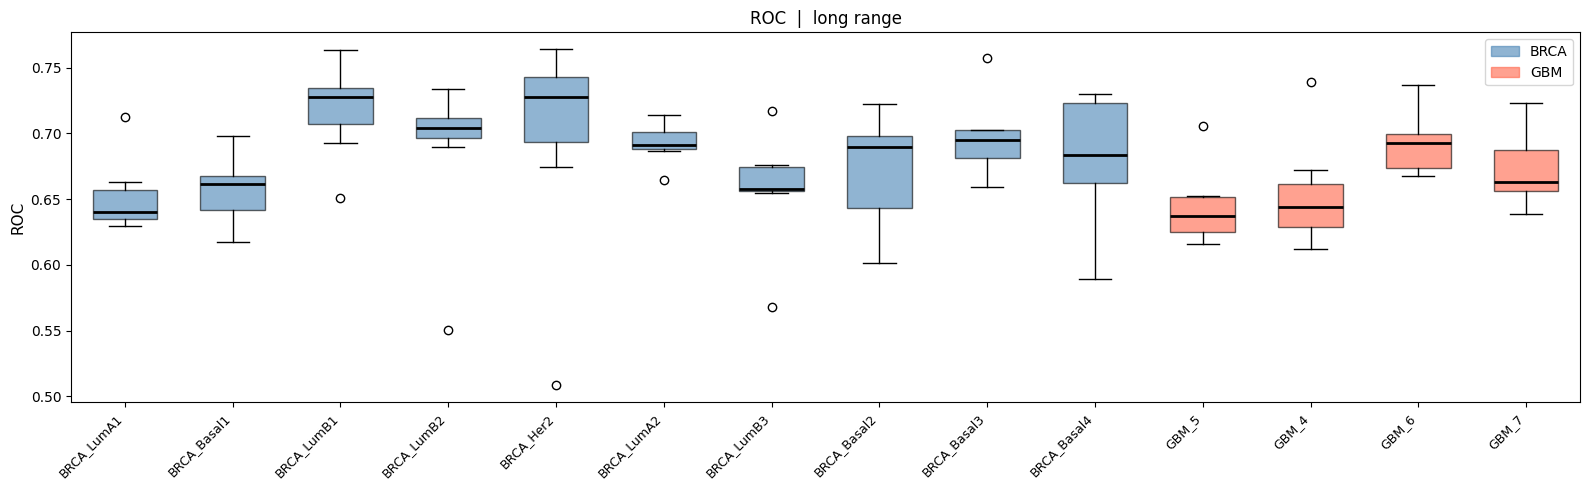

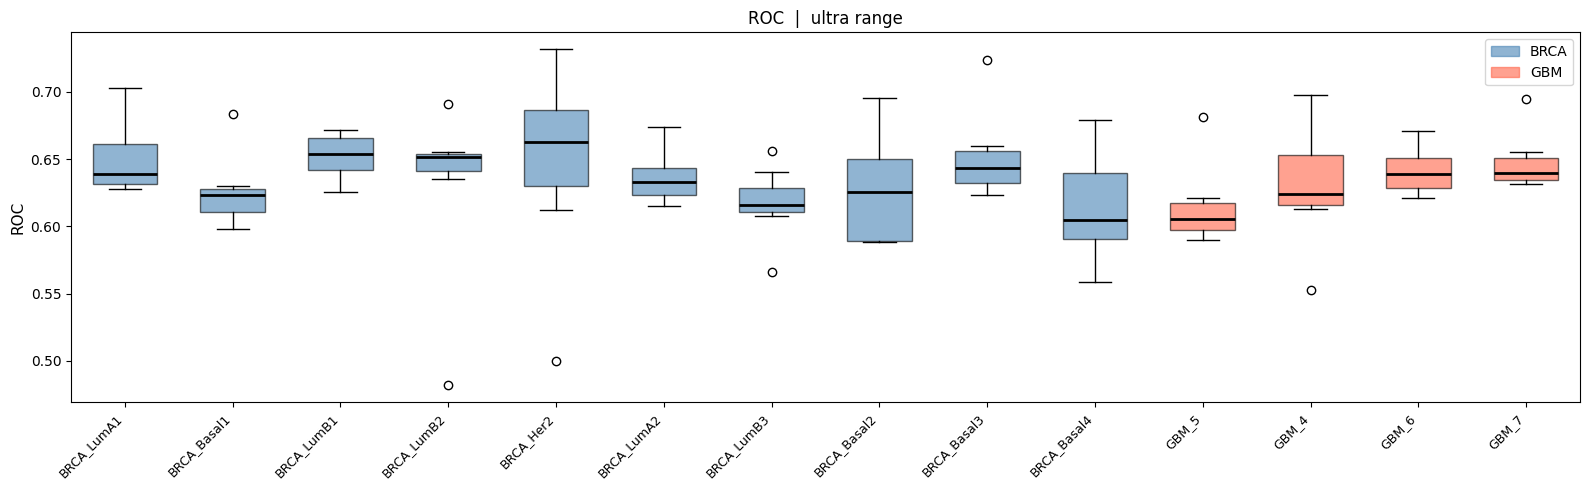

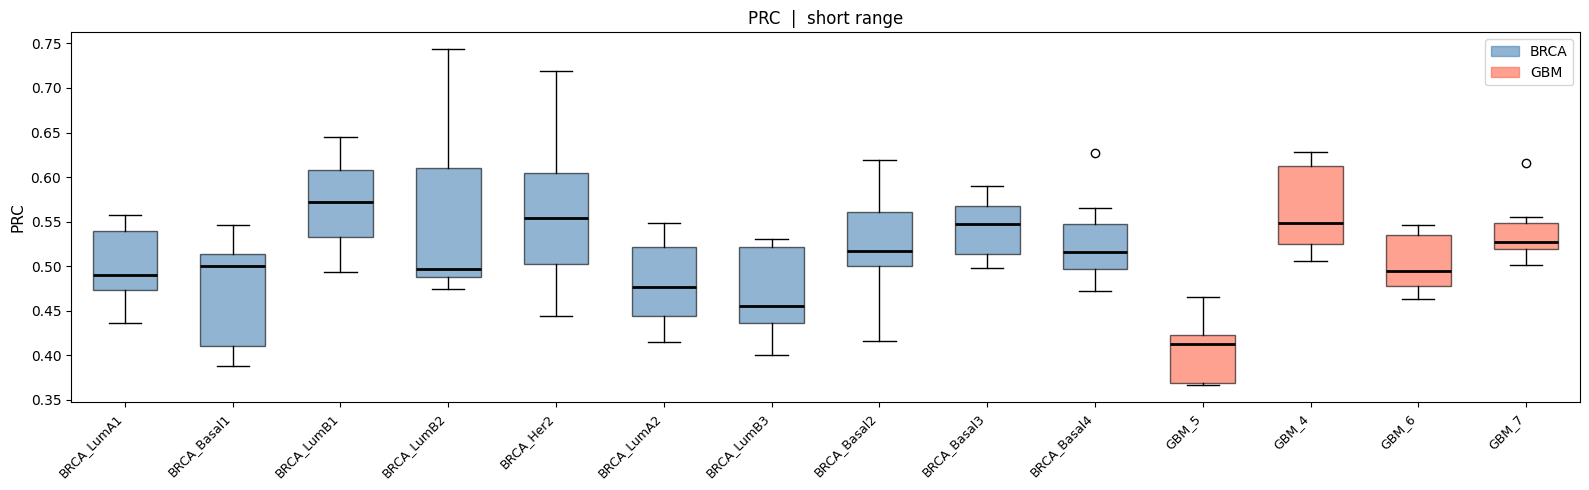

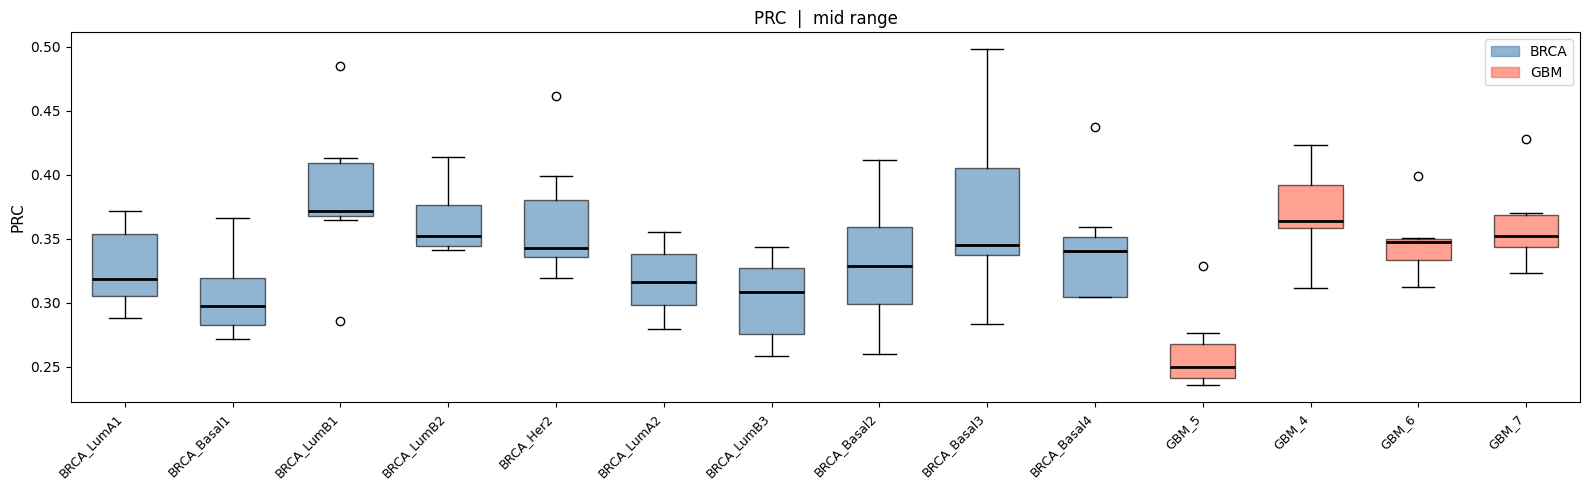

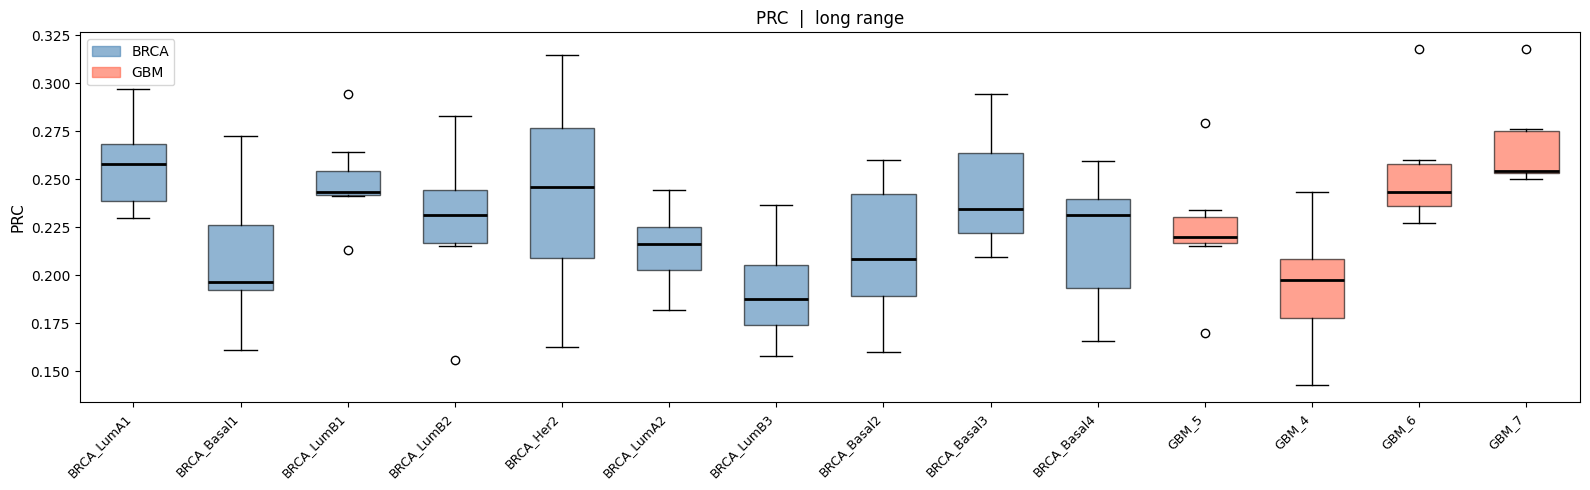

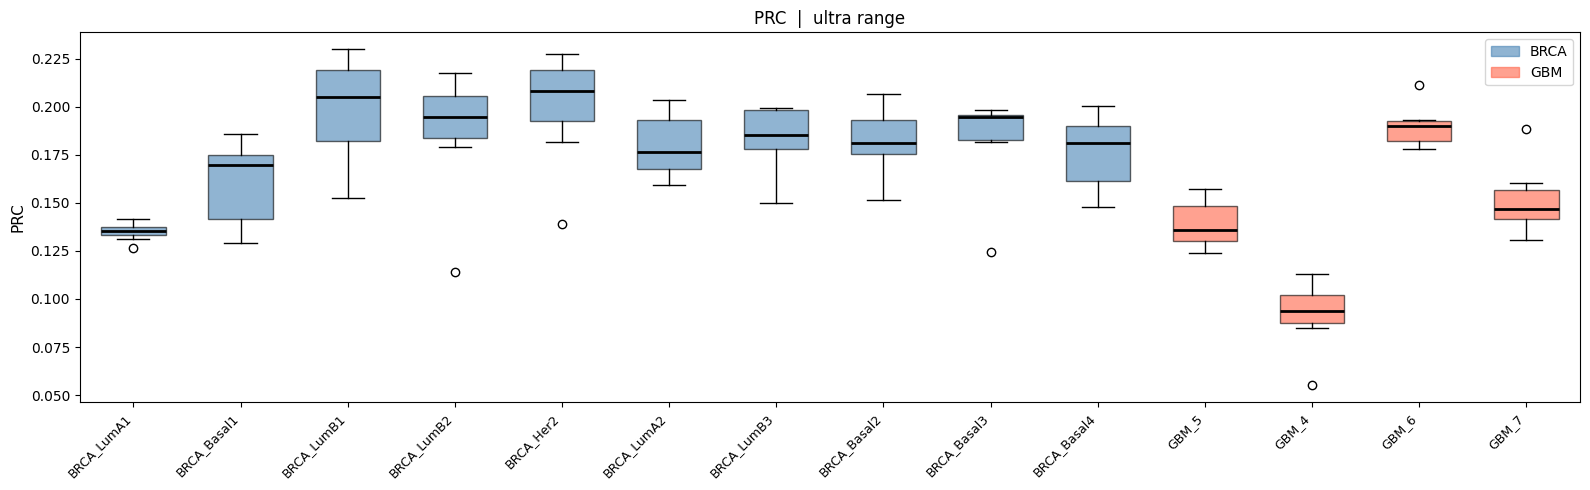

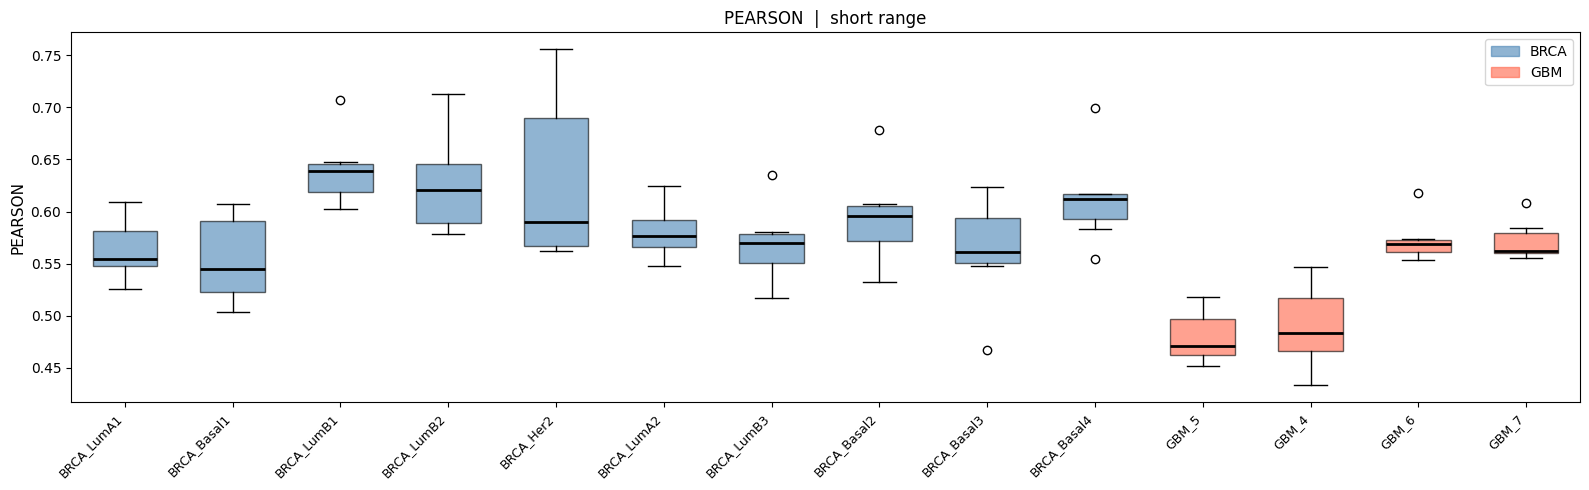

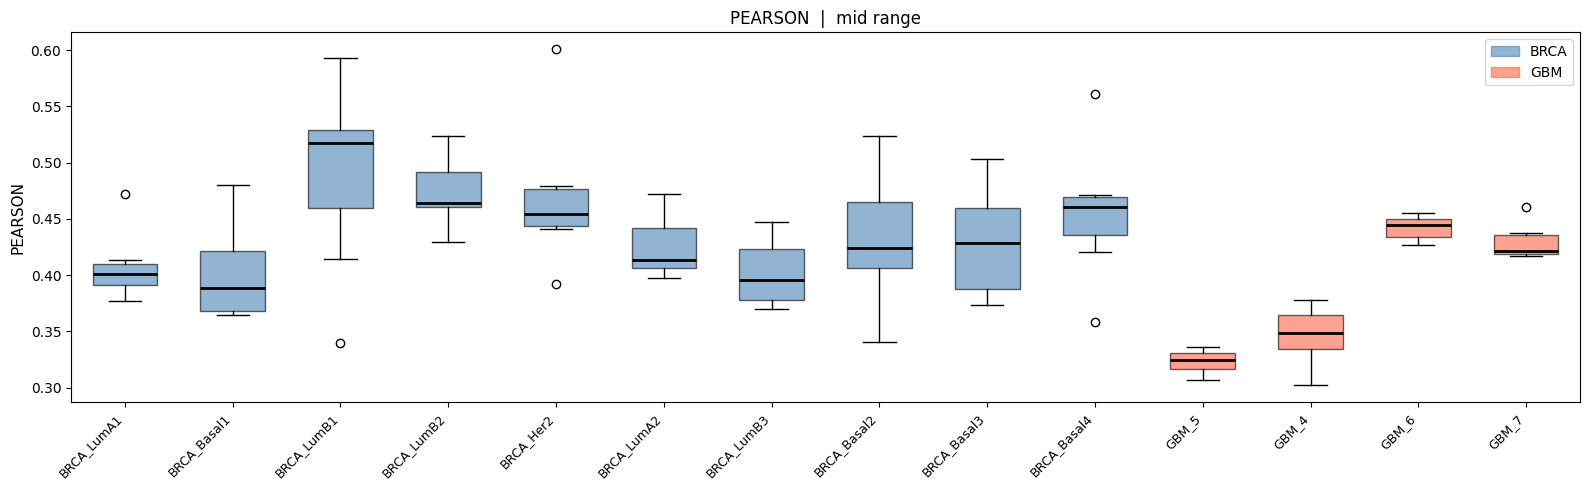

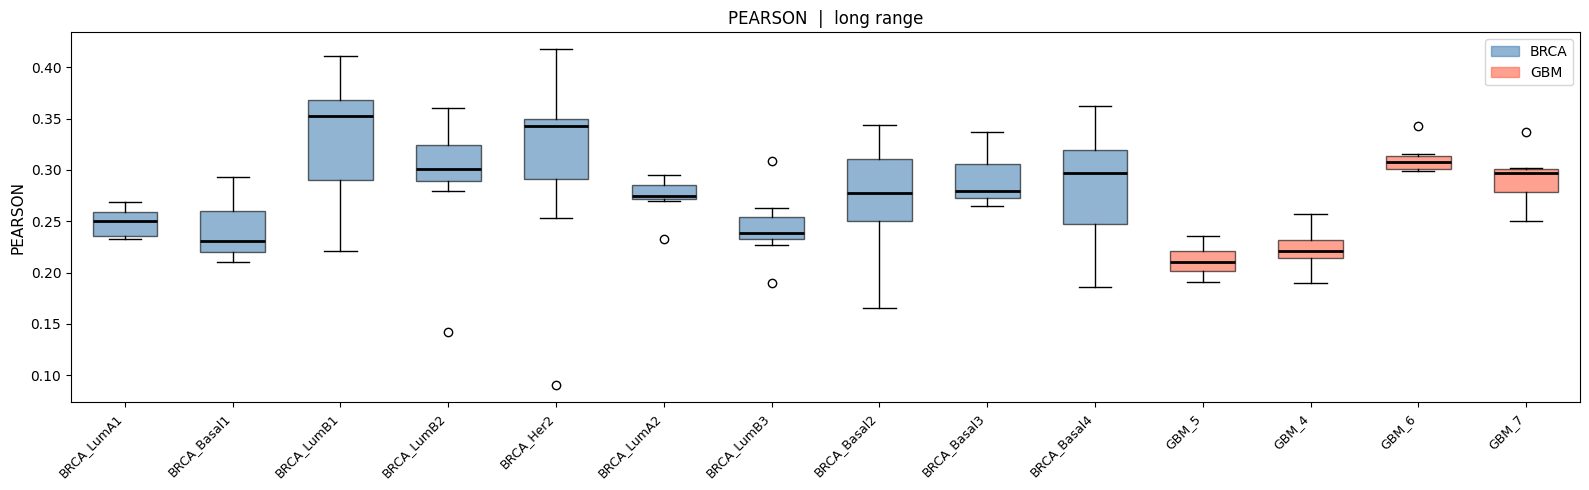

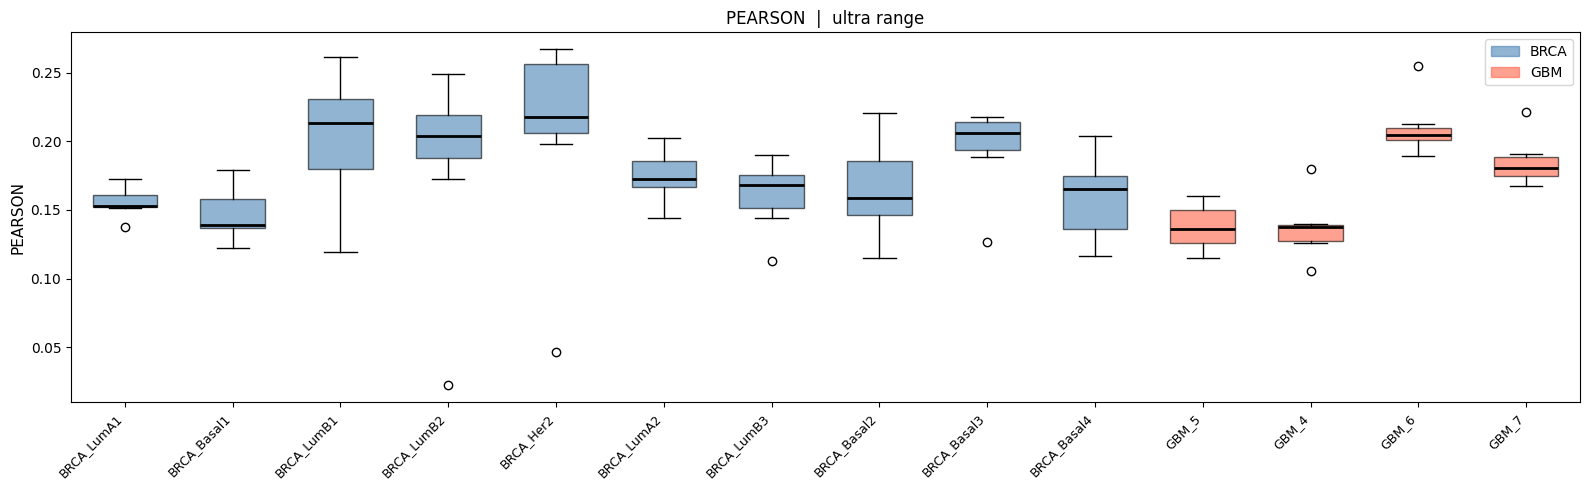

In [19]:
#dr_labels = {dr: label for dr, label in zip(distance_ranges, ["short", "mid", "long", "ultra"])}
type_colors = {"BRCA": "steelblue", "GBM": "tomato"}
for metric in metrics:
    for dr in distance_ranges:
        fig, ax = plt.subplots(figsize=(16, 5))

        box_data  = []
        positions = list(range(1, len(short_labels) + 1))

        for short in short_labels:
            chrom_vals = [
                all_results[short][metric][dr][str(c).replace("chr", "")]
                for c in chrom_list
            ]
            box_data.append(chrom_vals)

        bp = ax.boxplot(box_data, positions=positions,
                        patch_artist=True, widths=0.6,
                        medianprops=dict(color="black", linewidth=2))

        # Color boxes by cohort
        for patch, s_type in zip(bp["boxes"], sample_types):
            patch.set_facecolor(type_colors[s_type])
            patch.set_alpha(0.6)

        ax.set_xticks(positions)
        ax.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=9)
        ax.set_ylabel(metric.upper(), fontsize=11)
        ax.set_title(f"{metric.upper()}  |  {dr_labels[dr]} range", fontsize=12)

        legend_handles = [mpatches.Patch(color=type_colors[t], alpha=0.6, label=t)
                          for t in ["BRCA", "GBM"]]
        ax.legend(handles=legend_handles, loc="best")

        plt.tight_layout()
        plt.show()